# V3 — Macro-anchored rates-native allocation: synthetic lab or real data

This notebook keeps the **synthetic controlled world** from V2, but adds a clean
`USE_REAL_DATA` switch:

```python
USE_REAL_DATA = False   # synthetic controlled lab
USE_REAL_DATA = True    # download real FRED/Yahoo data
```

The idea is to make the framework usable in two modes:

1. **Synthetic mode** — a controlled Nelson–Siegel world where the assumed effects are embedded. This is a mechanics check, not empirical evidence.
2. **Real-data mode** — a real US rates/equity dataset using FRED yield curves and an equity index proxy. This turns the notebook into an empirical TAA / systematic multi-asset allocation prototype.

The full pipeline is:

1. Macro-consistent rate anchor.
2. Simple V1 equity/bond/cash TAA baseline using a 10Y rate gap.
3. V2/V3 rates-native extension using yield-curve PCA, level/slope/curvature gaps, carry/rolldown/convexity, and a curve-aware bond sleeve.
4. Cross-asset allocation with volatility, inflation and stock-bond-correlation risk controls.

**Important.** Real-data mode is intentionally simple and transparent. The FRED/yfinance data choices are proxies, not institutional-grade total-return curves or point-in-time macro datasets.


In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.linalg import eigh
import warnings

np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110, "font.size": 9})
rng = np.random.default_rng(7)

# ----------------------------- data mode ------------------------------------------
# False = keep the synthetic controlled world; True = download real FRED/Yahoo data.
USE_REAL_DATA = True
REAL_START = "2004-01-01"        # T10YIE starts in 2003; 2004 gives cleaner monthly data
REAL_END = None                  # None = latest available when the notebook is run

# ----------------------------- parameters (economic assumptions live here) ---------
MATS = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]); K = len(MATS)
I10  = int(np.where(MATS == 10)[0][0])
SYNTHETIC_T = 420                # months in synthetic mode
NS_LAMBDA = 2.0                  # Nelson-Siegel decay (years)
BURN_MONTHS = 120                # cap for PCA / parameter-estimation burn-in

PI_TARGET = 0.02
ASSUMED_TP = 0.005               # constant term premium baked into the LEVEL anchor
RSTAR_MIN = 36                   # burn-in for expanding r* proxy
Z_MIN, Z_CLIP, TANH_L = 36, 3.0, 1.0
G1_SLOPE = 2.0                   # policy-gap -> NS slope-param sensitivity (anchor)

# curve-trade tilt amplitudes for the long-only bucket sleeve
A_DUR, A_SLOPE, A_CURV = 0.18, 0.14, 0.10
WB0 = np.array([0.30, 0.30, 0.40])     # front / belly / long baseline weights

# cross-asset allocation
W_EQ0, W_BD0 = 0.50, 0.40
A_EQ, A_BOND = 0.20, 0.20
VOL_TARGET, M_MAX, W_MAX = 0.10, 1.5, 0.9
VOL_WIN, CORR_WIN = 12, 36
B_INFL, C_RV = 8.0, 0.10
TC, PPY = 0.0010, 12

# FRED symbols used in real-data mode.
FRED_CURVE = {
    0.25: "DGS3MO", 0.5: "DGS6MO", 1: "DGS1", 2: "DGS2", 3: "DGS3",
    5: "DGS5", 7: "DGS7", 10: "DGS10", 20: "DGS20", 30: "DGS30"
}
FRED_EXTRA = ["T10YIE", "FEDFUNDS", "SP500"]  # breakeven inflation, cash-rate proxy, equity fallback

def ns_loadings(mats, lam):
    x = mats / lam
    f1 = np.ones_like(mats, dtype=float)
    f2 = (1 - np.exp(-x)) / x
    f3 = f2 - np.exp(-x)
    return f1, f2, f3

F1L, F2L, F3L = ns_loadings(MATS, NS_LAMBDA)
print("data mode:", "REAL" if USE_REAL_DATA else "SYNTHETIC", "| maturities:", MATS)


data mode: REAL | maturities: [ 0.25  0.5   1.    2.    3.    5.    7.   10.   20.   30.  ]


## 1. Data mode (V3.1)

`USE_REAL_DATA=True` pulls **real** data; the curve comes from **pandas_datareader / FRED** (10 real constant-maturity tenors, so no interpolation), falling back to the **US Treasury** full par curve (different infrastructure, robust if FRED times out) and finally to **Yahoo** 4-point indices fitted with a **Nelson-Siegel** curve instead of a straight line. Inflation expectations use **FRED T10YIE**; the equity earnings yield uses **Shiller CAPE** (`E/P = 1/CAPE`). If a real macro input is missing the run prints a **loud banner** and marks the result as only partially testing the thesis — because a constant inflation or earnings yield silently switches the macro logic off.

`USE_REAL_DATA=False` keeps the synthetic Nelson-Siegel lab (mechanics check only). Both modes return the same objects, so every downstream cell is mode-agnostic.

In [2]:
# ===== V3.1 DATA LAYER =======================================================
# Real-data engine rebuilt:
#   * curve:      pandas_datareader FRED (10 real tenors)  ->  US Treasury full
#                 par curve (different infra, robust if FRED times out)  ->  Yahoo
#                 4-pt indices fitted with a Nelson-Siegel curve (not linear).
#   * inflation:  FRED T10YIE (real 10Y breakeven)         -> LOUD constant fallback
#   * earnings y: Shiller CAPE, E/P = 1/CAPE               -> LOUD constant fallback
#   * equity:     SPY total return (yfinance, auto-adjust) -> FRED SP500 price
# Fallbacks are LOUD: if a real macro input is missing the run says so, because a
# constant inflation / earnings yield silently turns off the macro thesis.
import warnings, socket, io, re

# ---- data-source config (model params stay in the first cell) ----
USE_TREASURY_FALLBACK = True
USE_YAHOO_FALLBACK    = True
STRICT_REAL_DATA      = False     # True -> raise instead of silently using synthetic
NET_TIMEOUT           = 6
SHORT_RATE_FRED       = "DTB3"    # 3M T-bill cash proxy (falls back to curve front)
CAPE_GITHUB_CSV  = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"
CAPE_SHILLER_XLS = "http://www.econ.yale.edu/~shiller/data/ie_data.xls"
NS_LAM_GRID = np.linspace(0.4, 6.0, 29)

def _loud(msg):
    bar = "!" * 78
    print("\n" + bar + "\n!!  " + msg + "\n" + bar + "\n")

def _can_reach(host, port=443, timeout=3.0):
    try:
        socket.create_connection((host, port), timeout=timeout).close(); return True
    except Exception:
        return False

# ---------- Nelson-Siegel curve interpolation (replaces 4-point linear) ----------
def _ns_basis(mats, lam):
    x = np.asarray(mats, float) / lam
    f0 = np.ones_like(x)
    with np.errstate(divide="ignore", invalid="ignore"):
        f1 = np.where(x == 0, 1.0, (1.0 - np.exp(-x)) / x)
    f2 = f1 - np.exp(-x)
    return np.column_stack([f0, f1, f2])

def _safe_interp(om, oy, tgt):
    order = np.argsort(om); om, oy = np.asarray(om)[order], np.asarray(oy)[order]
    try:
        from scipy.interpolate import PchipInterpolator       # monotone cubic, no overshoot
        return PchipInterpolator(om, oy, extrapolate=True)(tgt)
    except Exception:
        return np.interp(tgt, om, oy)

def fit_ns_curve(obs_mats, obs_yields, target_mats, lam_grid=NS_LAM_GRID):
    om = np.asarray(obs_mats, float); oy = np.asarray(obs_yields, float)
    ok = np.isfinite(om) & np.isfinite(oy); om, oy = om[ok], oy[ok]
    tgt = np.asarray(target_mats, float)
    if len(om) < 3:
        return _safe_interp(om, oy, tgt)
    best = None
    for lam in lam_grid:
        Xo = _ns_basis(om, lam); beta, *_ = np.linalg.lstsq(Xo, oy, rcond=None)
        sse = float(np.sum((oy - Xo @ beta) ** 2))
        if best is None or sse < best[0]:
            best = (sse, lam, beta)
    _, lam, beta = best
    return _ns_basis(tgt, lam) @ beta

def build_curve_row(obs_mats, obs_yields, target_mats, sparse_threshold=6):
    om = np.asarray(obs_mats, float); oy = np.asarray(obs_yields, float)
    ok = np.isfinite(oy); om, oy = om[ok], oy[ok]; tgt = np.asarray(target_mats, float)
    if len(om) == 0:
        return np.full(len(tgt), np.nan)
    if len(om) < sparse_threshold:                  # sparse (Yahoo) -> Nelson-Siegel
        return fit_ns_curve(om, oy, tgt)
    out = np.full(len(tgt), np.nan)                  # dense -> exact match + fill rare gaps
    for j, m in enumerate(tgt):
        hit = np.where(np.isclose(om, m, atol=1e-6))[0]
        if len(hit):
            out[j] = oy[hit[0]]
    miss = ~np.isfinite(out)
    if miss.any():
        out[miss] = _safe_interp(om, oy, tgt[miss])
    return out

def assemble_curve_panel(obs_mats, obs_panel, target_mats):
    T = len(obs_panel); Y = np.empty((T, len(target_mats)))
    for t in range(T):
        Y[t] = build_curve_row(obs_mats, obs_panel[t], target_mats)
    return Y

# ---------- curve sources ----------
def _fred_via_pdr(ids, start, end):
    import pandas_datareader.data as web              # tried first, per request
    return web.DataReader(ids, "fred", start, end)

def _fred_via_csv(ids, start, end):
    import urllib.request                             # robust fallback (works on any pandas)
    cols = []
    for sid in ids:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}"
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        txt = urllib.request.urlopen(req, timeout=NET_TIMEOUT).read().decode("utf-8-sig", "replace")
        d = pd.read_csv(io.StringIO(txt), na_values=["."])
        datecol = [c for c in d.columns if c.lower() in ("observation_date", "date")][0]
        d[datecol] = pd.to_datetime(d[datecol]); d = d.set_index(datecol)
        cols.append(pd.to_numeric(d.iloc[:, 0], errors="coerce").rename(sid))
    out = pd.concat(cols, axis=1).sort_index()
    if start is not None: out = out.loc[pd.Timestamp(start):]
    if end is not None:   out = out.loc[:pd.Timestamp(end)]
    return out

def fred_series(ids, start, end):
    """FRED via pandas_datareader, with a direct-CSV fallback if pdr is incompatible
    with the installed pandas (a common breakage) or otherwise errors."""
    ids = ids if isinstance(ids, list) else [ids]
    try:
        return _fred_via_pdr(ids, start, end)
    except Exception as e:
        warnings.warn(f"pandas_datareader FRED failed ({type(e).__name__}: {e}); using direct FRED CSV.")
        return _fred_via_csv(ids, start, end)

def fetch_curve_fred(start, end):
    if not _can_reach("fred.stlouisfed.org"):
        raise RuntimeError("FRED unreachable")
    ids = [FRED_CURVE[m] for m in MATS]
    monthly = (fred_series(ids, start, end) / 100.0).resample("ME").last()
    return monthly.index, np.array(list(MATS), float), monthly[ids].to_numpy(float)

def _treasury_col_to_mat(col):
    m = re.match(r"\s*([\d.]+)\s*(mo|month|months|yr|year|years)", str(col).strip().lower())
    if not m:
        return None
    v = float(m.group(1))
    return v / 12.0 if m.group(2).startswith(("mo", "month")) else v

def fetch_curve_treasury(start, end):
    if not _can_reach("home.treasury.gov"):
        raise RuntimeError("US Treasury unreachable")
    import urllib.request
    end_year = (pd.Timestamp(end) if end else pd.Timestamp.today()).year
    frames = []
    for y in range(pd.Timestamp(start).year, end_year + 1):
        url = ("https://home.treasury.gov/resource-center/data-chart-center/interest-rates/"
               f"daily-treasury-rates.csv/{y}/all?type=daily_treasury_yield_curve&"
               f"field_tdr_date_value={y}&page&_format=csv")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        txt = urllib.request.urlopen(req, timeout=NET_TIMEOUT).read().decode("utf-8", "replace")
        frames.append(pd.read_csv(io.StringIO(txt)))
    raw = pd.concat(frames, ignore_index=True)
    raw["Date"] = pd.to_datetime(raw["Date"]); raw = raw.sort_values("Date").set_index("Date")
    mats, cols = [], []
    for c in raw.columns:
        mm = _treasury_col_to_mat(c)
        if mm is not None:
            mats.append(mm); cols.append(c)
    monthly = (raw[cols].apply(pd.to_numeric, errors="coerce") / 100.0).resample("ME").last()
    return monthly.index, np.array(mats, float), monthly.to_numpy(float)

def fetch_curve_yahoo(start, end):
    if not (_can_reach("query1.finance.yahoo.com") or _can_reach("query2.finance.yahoo.com")):
        raise RuntimeError("Yahoo unreachable")
    import yfinance as yf
    tk = {"^IRX": 0.25, "^FVX": 5.0, "^TNX": 10.0, "^TYX": 30.0}
    px = yf.download(list(tk), start=start, end=end, progress=False)["Close"]
    monthly = (px.resample("ME").last() / 100.0)
    obs_mats = np.array([tk[c] for c in monthly.columns], float)
    return monthly.index, obs_mats, monthly.to_numpy(float)

# ---------- other real inputs ----------
def fetch_breakeven(dates, start, end):
    try:
        if not _can_reach("fred.stlouisfed.org"):
            raise RuntimeError("FRED unreachable")
        s = fred_series("T10YIE", start, end)["T10YIE"] / 100.0
        m = s.resample("ME").last().reindex(dates).ffill()
        if m.notna().mean() > 0.5:
            return m.to_numpy(float), "FRED T10YIE (10Y breakeven)"
    except Exception as e:
        warnings.warn(f"breakeven (T10YIE) fetch failed: {e}")
    _loud("INFLATION EXPECTATIONS UNAVAILABLE -> CONSTANT 2%. "
          "The macro rate anchor and the inflation throttle are NOT being tested in this run.")
    return np.full(len(dates), PI_TARGET), "CONSTANT target (fallback; thesis untested)"

def _cape_from_shiller(dates):
    if not _can_reach("www.econ.yale.edu"):
        raise RuntimeError("Shiller site unreachable")
    df = pd.read_excel(CAPE_SHILLER_XLS, sheet_name="Data", skiprows=7)
    capecol = [c for c in df.columns if str(c).strip().upper() in ("CAPE", "P/E10", "P/E 10")]
    if not capecol:
        raise RuntimeError("CAPE column not found in Shiller workbook")
    yr = pd.to_numeric(df[df.columns[0]], errors="coerce")
    cape = pd.to_numeric(df[capecol[0]], errors="coerce")
    mon = (yr * 100 % 100).round().clip(1, 12)
    idx = pd.to_datetime(dict(year=yr.astype("Int64"), month=mon.astype("Int64"), day=1), errors="coerce")
    s = pd.Series((1.0 / cape).values, index=idx).dropna().sort_index()
    ep = s.resample("ME").last().reindex(dates).ffill()
    return ep.to_numpy(float), float(ep.notna().mean())

def _cape_from_github(dates):
    if not _can_reach("raw.githubusercontent.com"):
        raise RuntimeError("github unreachable")
    import urllib.request
    raw = urllib.request.urlopen(urllib.request.Request(CAPE_GITHUB_CSV,
          headers={"User-Agent": "Mozilla/5.0"}), timeout=NET_TIMEOUT).read()
    df = pd.read_csv(io.StringIO(raw.decode("utf-8")), parse_dates=["Date"]).set_index("Date")
    pe10 = pd.to_numeric(df["PE10"], errors="coerce").replace(0.0, np.nan)
    ep = (1.0 / pe10).resample("ME").last().reindex(dates).ffill()
    return ep.to_numpy(float), float(ep.notna().mean())

def fetch_earnings_yield(dates):
    for fn, name in [(_cape_from_shiller, "Shiller CAPE xls (1/CAPE)"),
                     (_cape_from_github,  "Shiller CAPE via datahub CSV (1/CAPE)")]:
        try:
            ep, cov = fn(dates)
            if cov > 0.5:
                if cov < 0.95:
                    warnings.warn(f"{name}: {cov:.0%} date coverage; tail carried forward (CAPE is slow-moving).")
                return ep, name
        except Exception as e:
            warnings.warn(f"{name} failed: {e}")
    _loud("EARNINGS YIELD UNAVAILABLE -> CONSTANT 4%. "
          "The equity valuation (ERP) signal is NOT being tested in this run.")
    return np.full(len(dates), 0.04), "CONSTANT 4% (fallback; ERP untested)"

def fetch_equity(dates, start, end):
    try:
        if _can_reach("query1.finance.yahoo.com") or _can_reach("query2.finance.yahoo.com"):
            import yfinance as yf
            px = yf.download("SPY", start=start, end=end, auto_adjust=True, progress=False)["Close"]
            if hasattr(px, "columns"):
                px = px.iloc[:, 0]
            r = px.resample("ME").last().reindex(dates).ffill().pct_change().fillna(0.0)
            if r.abs().sum() > 0:
                return r.to_numpy(float), "SPY total return (yfinance, auto-adjusted)"
    except Exception as e:
        warnings.warn(f"SPY equity fetch failed: {e}")
    try:
        if _can_reach("fred.stlouisfed.org"):
            s = fred_series("SP500", start, end)["SP500"]
            r = s.resample("ME").last().reindex(dates).ffill().pct_change().fillna(0.0)
            return r.to_numpy(float), "FRED SP500 price return (no dividends)"
    except Exception as e:
        warnings.warn(f"FRED SP500 fetch failed: {e}")
    _loud("EQUITY RETURNS UNAVAILABLE -> zeros. Cross-asset results are meaningless in this run.")
    return np.zeros(len(dates)), "ZERO (fallback)"

# ---------- orchestrator ----------
def make_real_data():
    sources = [(fetch_curve_fred, "FRED (10 real tenors)")]
    if USE_TREASURY_FALLBACK:
        sources.append((fetch_curve_treasury, "US Treasury par curve (full)"))
    if USE_YAHOO_FALLBACK:
        sources.append((fetch_curve_yahoo, "Yahoo 4-pt + Nelson-Siegel"))

    curve, curve_source, log = None, None, []
    for fn, label in sources:
        try:
            idx, obs_mats, obs_panel = fn(REAL_START, REAL_END)
            Y = assemble_curve_panel(obs_mats, obs_panel, np.array(list(MATS), float))
            good = np.isfinite(Y).all(1)
            idx, Y = idx[good], Y[good]
            if len(idx) >= 60:
                curve, curve_source = (idx, Y), label; break
            log.append(f"{label}: only {len(idx)} usable months")
        except Exception as e:
            log.append(f"{label}: {type(e).__name__}: {e}")
            print(f"curve source '{label}' failed -> {type(e).__name__}: {e}")

    if curve is None:
        msg = "All curve sources failed: " + " | ".join(log)
        if STRICT_REAL_DATA:
            raise RuntimeError(msg)
        _loud("REAL CURVE UNAVAILABLE (likely no internet here) -> FALLING BACK TO SYNTHETIC. "
              "On a networked machine this pulls real FRED/Treasury data.")
        d = make_synthetic_data()
        d["DATA_LABEL"] = "synthetic fallback (no real curve)"
        d["RESULT_NOTE"] = "synthetic fallback; real data unavailable in this environment"
        return d

    dates, Y = curve; T = len(dates)
    print(f"Curve source: {curve_source} | {dates[0].date()} -> {dates[-1].date()} | {T} months")
    pi, pi_src = fetch_breakeven(dates, REAL_START, REAL_END)
    ep, ep_src = fetch_earnings_yield(dates)
    eq_ret, eq_src = fetch_equity(dates, REAL_START, REAL_END)

    short, short_src = None, None
    try:
        if _can_reach("fred.stlouisfed.org"):
            s = fred_series(SHORT_RATE_FRED, REAL_START, REAL_END)[SHORT_RATE_FRED] / 100.0
            short = s.resample("ME").last().reindex(dates).ffill().to_numpy(float)
            short_src = f"FRED {SHORT_RATE_FRED}"
    except Exception:
        pass
    if short is None or not np.isfinite(short).all():
        short, short_src = Y[:, 0].copy(), "curve front (3M)"

    rstar_proxy = pd.Series(short - pi, index=dates).expanding(RSTAR_MIN).mean().bfill().to_numpy()
    neutral = rstar_proxy + pi; policy_gap = short - neutral
    D, C, dY, roll, RET = _make_roll_and_returns_from_curve(Y, dates, np.array(list(MATS), float), noise_scale=0.0)
    rf = short / 12.0

    print(f"Inflation: {pi_src} | Earnings yield: {ep_src} | Equity: {eq_src} | Short: {short_src}")
    note = "empirical backtest"
    if "CONSTANT" in pi_src or "CONSTANT" in ep_src:
        note = "PARTIAL real data — some macro inputs are constants (see warnings); thesis only partially tested"
    return dict(DATA_LABEL=f"real data: {curve_source}", RESULT_NOTE=note,
                dates=dates, T=T, rstar=rstar_proxy, pi=pi, neutral=neutral, short=short,
                policy_gap=policy_gap, Y=Y, D=D, C=C, dY=dY, roll=roll, RET=RET,
                ep=ep, eq_ret=eq_ret, rf=rf)


# ---------- synthetic engine (unchanged) ----------
def _make_roll_and_returns_from_curve(Y, dates, mats, noise_scale=0.0, rng=None):
    T, K = Y.shape
    D = mats.astype(float); C = mats ** 2
    dY = np.vstack([np.zeros((1, K)), np.diff(Y, axis=0)])
    h = 1 / 12
    roll = np.zeros((T, K))
    for t in range(T):
        yroll = np.interp(np.maximum(mats - h, mats.min()), mats, Y[t])
        roll[t] = D * (Y[t] - yroll)
    carry = Y / 12.0
    price = -D[None, :] * dY + 0.5 * C[None, :] * dY ** 2
    eps = 0 if noise_scale == 0 else noise_scale * rng.standard_normal((T, K))
    RET = carry + roll + price + eps
    return D, C, dY, roll, RET

def make_synthetic_data():
    T = SYNTHETIC_T
    dates = pd.date_range("1990-01-31", periods=T, freq="ME")
    rstar = np.clip(np.linspace(0.025, 0.005, T) +
                    0.002 * np.cumsum(rng.standard_normal(T)) / np.sqrt(T), -0.005, 0.04)
    pi = np.empty(T); pi[0] = 0.035
    pimean = 0.025 + 0.010 * np.sin(np.linspace(0, 3 * np.pi, T))
    surge = np.zeros(T); s0 = T - 48
    surge[s0:s0 + 18] = np.linspace(0, 0.03, 18); surge[s0 + 18:s0 + 36] = np.linspace(0.03, 0, 18)
    for t in range(1, T):
        pi[t] = pi[t - 1] + 0.25 * ((pimean[t] + surge[t]) - pi[t - 1]) + 0.0035 * rng.standard_normal()
    pi = np.clip(pi, 0, 0.09)
    neutral = rstar + pi
    short = np.empty(T); short[0] = neutral[0]
    for t in range(1, T):
        short[t] = short[t - 1] + 0.20 * (neutral[t] - short[t - 1]) + 0.004 * rng.standard_normal()
    short = np.clip(short, 0, 0.12)
    tp = np.linspace(0.012, -0.002, T) + 0.0015 * np.cumsum(rng.standard_normal(T)) / np.sqrt(T)
    policy_gap = short - neutral
    corr_le = np.where(pi > 0.03, -0.5, 0.4)
    corr_le = pd.Series(corr_le).ewm(span=6).mean().to_numpy()
    z_lvl = rng.standard_normal(T); z_eq_ind = rng.standard_normal(T)
    eq_shock = corr_le * z_lvl + np.sqrt(np.clip(1 - corr_le ** 2, 0, 1)) * z_eq_ind
    b0 = np.empty(T); b1 = np.empty(T); b2 = np.empty(T)
    b0[0] = rstar[0] + pi[0] + tp[0]; b1[0] = G1_SLOPE * policy_gap[0]; b2[0] = 0.0
    for t in range(1, T):
        b0[t] = b0[t - 1] + 0.10 * ((rstar[t] + pi[t] + tp[t]) - b0[t - 1]) + 0.0030 * z_lvl[t]
        b1[t] = b1[t - 1] + 0.15 * (G1_SLOPE * policy_gap[t] - b1[t - 1]) + 0.0030 * rng.standard_normal()
        b2[t] = b2[t - 1] + 0.20 * (0.0 - b2[t - 1]) + 0.0035 * rng.standard_normal()
    Y = b0[:, None] * F1L[None, :] + b1[:, None] * F2L[None, :] + b2[:, None] * F3L[None, :]
    Y = np.clip(Y + 0.0006 * rng.standard_normal((T, K)), 0.0005, 0.16)
    D, C, dY, roll, RET = _make_roll_and_returns_from_curve(Y, dates, MATS, noise_scale=0.0008, rng=rng)
    ep = np.empty(T); ep[0] = 0.055
    epmean = 0.055 + 0.015 * np.sin(np.linspace(0.5, 2.5 * np.pi, T))
    for t in range(1, T):
        ep[t] = ep[t - 1] + 0.06 * (epmean[t] - ep[t - 1]) + 0.003 * rng.standard_normal()
    ep = np.clip(ep, 0.02, 0.11)
    real_y10 = Y[:, I10] - pi
    erp_true = 0.6 * (ep - real_y10) + 0.02
    eqvol = (0.16 / np.sqrt(12)) * (1 + 0.3 * np.abs(np.roll(eq_shock, 1)))
    eq_ret = short / 12 + erp_true / 12 + eqvol * eq_shock
    rf = short / 12
    return dict(DATA_LABEL="synthetic", RESULT_NOTE="mechanics check, not empirical evidence",
                dates=dates, T=T, rstar=rstar, pi=pi, neutral=neutral, short=short,
                policy_gap=policy_gap, Y=Y, D=D, C=C, dY=dY, roll=roll, RET=RET,
                ep=ep, eq_ret=eq_ret, rf=rf)

# ---------- choose engine ----------
data = make_real_data() if USE_REAL_DATA else make_synthetic_data()
globals().update(data)
BURN = min(BURN_MONTHS, max(60, int(0.40 * T)))
Ydf = pd.DataFrame(Y, index=dates, columns=[f"{m:g}y" for m in MATS])
RETdf = pd.DataFrame(RET, index=dates, columns=Ydf.columns)
print(f"\nData mode: {DATA_LABEL} | sample: {dates[0].date()} to {dates[-1].date()} | T={T} months | BURN={BURN}")
print("Curve panel:", Ydf.shape)
print("Sample yields (%) at first / mid / last month:")
print((100 * Ydf.iloc[[0, T // 2, -1]]).round(2))


Curve source: FRED (10 real tenors) | 2004-01-31 -> 2026-07-31 | 271 months


/tmp/ipykernel_12914/3424782150.py:217: UserWarning: Shiller CAPE xls (1/CAPE) failed: Shiller site unreachable
  warnings.warn(f"{name} failed: {e}")


Inflation: FRED T10YIE (10Y breakeven) | Earnings yield: Shiller CAPE via datahub CSV (1/CAPE) | Equity: SPY total return (yfinance, auto-adjusted) | Short: FRED DTB3

Data mode: real data: FRED (10 real tenors) | sample: 2004-01-31 to 2026-07-31 | T=271 months | BURN=108
Curve panel: (271, 10)
Sample yields (%) at first / mid / last month:
            0.25y  0.5y    1y    2y    3y    5y    7y   10y   20y   30y
DATE                                                                   
2004-01-31  0.920 1.010 1.280 1.840 2.350 3.170 3.680 4.160 5.000 5.110
2015-04-30  0.010 0.060 0.240 0.580 0.910 1.430 1.790 2.050 2.490 2.750
2026-07-31  3.850 4.000 4.000 4.170 4.190 4.240 4.350 4.480 4.970 4.970


## 2. Yield-curve PCA → level, slope, curvature

PCA is run on monthly **yield changes** over the burn-in window. The first three components are treated as level / slope / curvature shapes. Loadings are then **fixed** and used to project factor *levels* for the whole sample. This keeps the backtest lag-correct and avoids look-ahead in the factor construction.


Explained variance  PC1..PC3: [0.7325 0.1954 0.0506]  cumulative: 0.9785


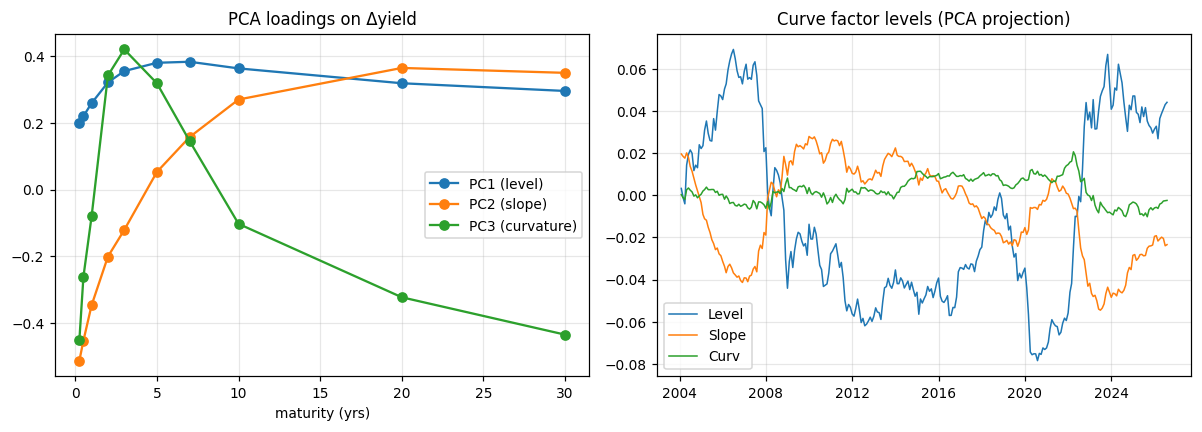

In [3]:
dY_burn = np.diff(Y[:BURN], axis=0)
Sigma = np.cov(dY_burn, rowvar=False)
vals, vecs = eigh(Sigma)
order = np.argsort(vals)[::-1]; vals, vecs = vals[order], vecs[:, order]
B = vecs[:, :3].copy()
# orient signs: level all-positive; slope increasing in maturity (=steepening); curvature belly-positive
if B[:, 0].mean() < 0:            B[:, 0] *= -1
if B[-1, 1] - B[0, 1] < 0:        B[:, 1] *= -1
if B[K//2, 2] < 0:                B[:, 2] *= -1
expl = vals/vals.sum()
print("Explained variance  PC1..PC3:", np.round(expl[:3], 4), " cumulative:", round(expl[:3].sum(), 4))

muY = Y[:BURN].mean(axis=0)
F = (Y - muY) @ B                                   # factor LEVELS: [Level, Slope, Curv]
Fdf = pd.DataFrame(F, index=dates, columns=["Level", "Slope", "Curv"])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, lab in enumerate(["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"]):
    ax[0].plot(MATS, B[:, i], marker="o", label=lab)
ax[0].set_xlabel("maturity (yrs)"); ax[0].set_title("PCA loadings on Δyield"); ax[0].legend()
for c in Fdf.columns: ax[1].plot(Fdf.index, Fdf[c], lw=1.0, label=c)
ax[1].set_title("Curve factor levels (PCA projection)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Factor mean reversion toward macro anchors

A macro anchor *curve* is built in Nelson–Siegel form from the macro inputs and projected into factor space. The **level** reverts to *r\*-proxy + expected inflation + term premium*; the **slope** reverts to a *policy-stance* level; **curvature** reverts to its statistical mean.

The reversion speed is now estimated more coherently from the anchor gap:

\[
\Delta F_{t+1} = a - \kappa(F_t-\hat F_t) + arepsilon_{t+1}
\]

rather than from reversion to a fixed historical mean. Expected factor changes map back to per-maturity expected yield changes via the PCA loadings.


Estimated monthly reversion speeds kappa: {'Level': np.float64(0.022), 'Slope': np.float64(0.01), 'Curv': np.float64(0.158)}


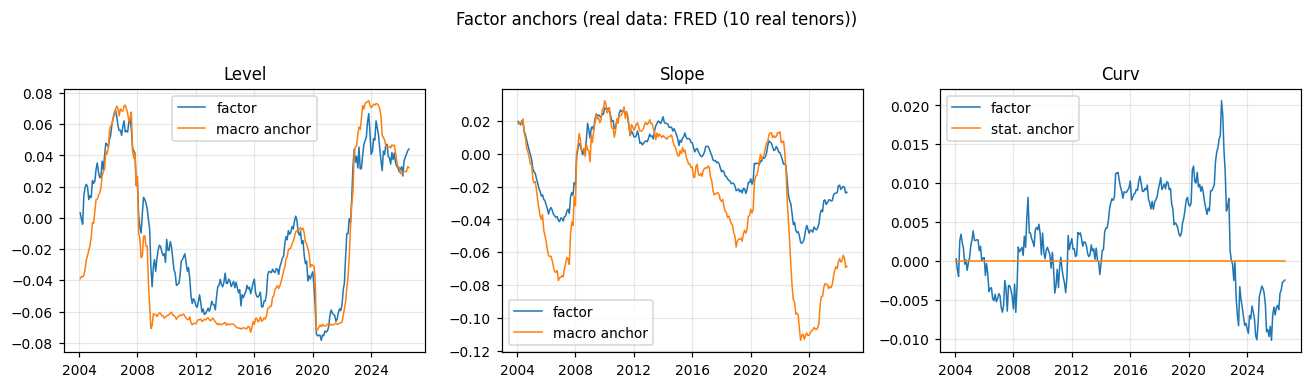

In [4]:
def zscore_exp(x, minp=Z_MIN, clip=Z_CLIP):
    s = pd.Series(np.asarray(x, dtype=float), index=dates)
    z = (s - s.expanding(minp).mean()) / s.expanding(minp).std()
    return z.clip(-clip, clip)

rstar_proxy = pd.Series(short - pi, index=dates).expanding(RSTAR_MIN).mean().bfill().to_numpy()
b0_anchor = rstar_proxy + pi + ASSUMED_TP            # level -> long yield (macro)
b1_anchor = G1_SLOPE * policy_gap                    # slope param -> policy stance (macro)
b2_anchor = np.zeros(T)                              # curvature -> flat
Yhat = b0_anchor[:,None]*F1L[None,:] + b1_anchor[:,None]*F2L[None,:] + b2_anchor[:,None]*F3L[None,:]
Fhat = (Yhat - muY) @ B
curv_target = F[:BURN, 2].mean()                     # curvature: statistical anchor

gap_F = F.copy()
gap_F[:, 0] = F[:, 0] - Fhat[:, 0]
gap_F[:, 1] = F[:, 1] - Fhat[:, 1]
gap_F[:, 2] = F[:, 2] - curv_target

# Estimate reversion speed from the anchor gap: ΔF_{t+1} = a - kappa * gap_t + eps.
kappa = np.zeros(3)
for i in range(3):
    y = np.diff(F[:BURN, i])
    x = gap_F[:BURN-1, i]
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 24 or np.nanstd(x[ok]) == 0:
        kappa[i] = 0.05
    else:
        slope = np.polyfit(x[ok], y[ok], 1)[0]
        kappa[i] = -slope
kappa = np.clip(kappa, 0.01, 1.0)
EdF = -kappa[None, :] * gap_F                        # expected monthly factor change
EdY = EdF @ B.T                                      # expected per-maturity yield change
print("Estimated monthly reversion speeds kappa:",
      dict(zip(["Level", "Slope", "Curv"], np.round(kappa, 3))))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for i, lab in enumerate(["Level", "Slope", "Curv"]):
    ax[i].plot(dates, F[:, i], lw=1.0, label="factor")
    tgt = Fhat[:, i] if i < 2 else np.full(T, curv_target)
    ax[i].plot(dates, tgt, lw=1.0, label="macro anchor" if i < 2 else "stat. anchor")
    ax[i].set_title(lab); ax[i].legend()
plt.suptitle(f"Factor anchors ({DATA_LABEL})", y=1.02)
plt.tight_layout(); plt.show()


## 4. Carry, roll-down and convexity by maturity

The expected one-month return of each maturity is *carry + roll-down + duration
repricing + convexity*, where the repricing uses the factor-implied $E[\Delta y(\tau)]$
from step 3 and convexity uses the trailing variance of yield changes. This turns the
curve view into an **expected-return curve** rather than a single number.

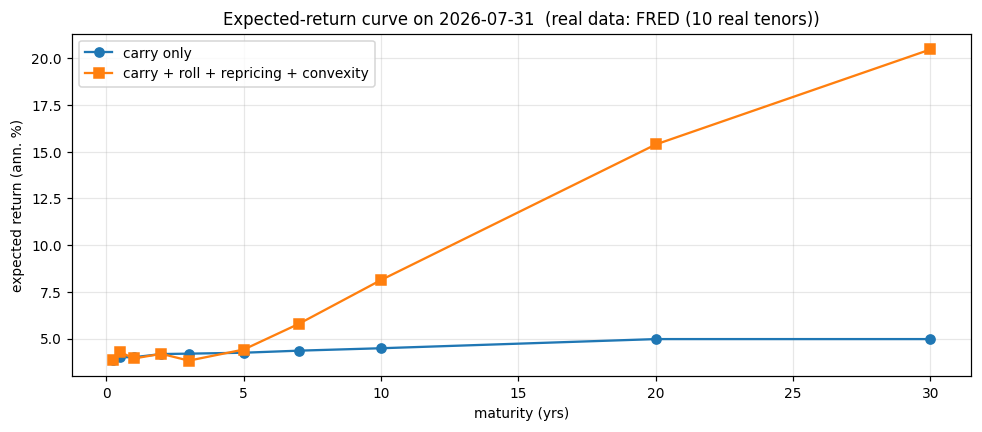

In [5]:
varY = pd.DataFrame(dY[1:], index=dates[1:]).rolling(VOL_WIN).var().reindex(dates).to_numpy()
carry_m = Y/12.0
repricing = -D[None, :]*EdY
convex = 0.5*C[None, :]*np.nan_to_num(varY)
ER_mat = carry_m + roll + repricing + convex        # expected monthly return per maturity
ERdf = pd.DataFrame(ER_mat, index=dates, columns=Ydf.columns)

dsel = -1
plt.figure(figsize=(9, 4))
plt.plot(MATS, 1200*carry_m[dsel], marker="o", label="carry only")
plt.plot(MATS, 1200*ER_mat[dsel], marker="s", label="carry + roll + repricing + convexity")
plt.xlabel("maturity (yrs)"); plt.ylabel("expected return (ann. %)")
plt.title(f"Expected-return curve on {dates[dsel].date()}  ({DATA_LABEL})")
plt.legend(); plt.tight_layout(); plt.show()


## 5. Curve-factor timing diagnostics

Each factor gap, standardised and squashed with `tanh`, becomes a view that the factor reverts toward its anchor. The stand-alone diagnostics below are **not yet fully implementable self-financing trades**; they are lagged factor-timing checks:

- level gap → duration view;
- slope gap → steepener/flattener view;
- curvature gap → butterfly view.

This isolates whether the model's factor views point in the right direction before those views are embedded into a long-only bond sleeve.


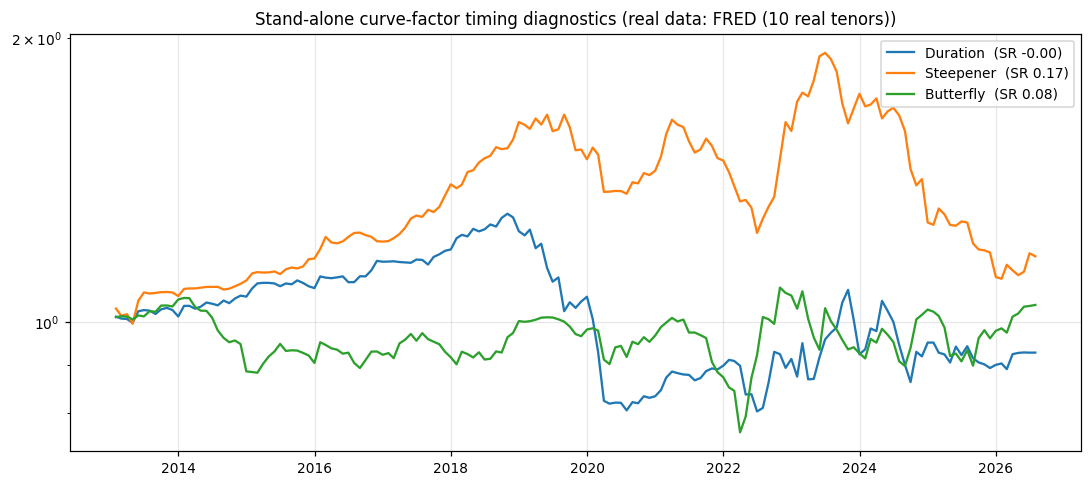

Curve-factor diagnostic Sharpe (real data: FRED (10 real tenors), empirical backtest):
Duration    -0.000
Steepener    0.170
Butterfly    0.080


In [6]:
z_g = np.column_stack([zscore_exp(gap_F[:, i]).to_numpy() for i in range(3)])
view_dur   = np.tanh(TANH_L *  z_g[:, 0])   # level rich -> expect lower yields -> long duration
view_steep = np.tanh(TANH_L * -z_g[:, 1])   # slope below anchor -> expect steepening
view_fly   = np.tanh(TANH_L * -z_g[:, 2])   # curvature below mean -> long butterfly

dF = np.vstack([np.zeros((1, 3)), np.diff(F, axis=0)])
def rv_pnl(view, change):                   # lagged view applied to realised factor change
    r = np.roll(view, 1) * change; r[:1] = 0
    return pd.Series(r, index=dates)
rv = pd.DataFrame({
    "Duration":  rv_pnl(view_dur,  -dF[:, 0]),   # profit if level falls
    "Steepener": rv_pnl(view_steep, dF[:, 1]),   # profit if slope rises
    "Butterfly": rv_pnl(view_fly,   dF[:, 2]),   # profit if curvature rises
}).iloc[BURN:]
rv = rv / rv.std() * (0.10/np.sqrt(12))          # scale each to ~10% ann vol
sharpe = rv.mean()/rv.std()*np.sqrt(12)

plt.figure(figsize=(10, 4.5))
for c in rv.columns:
    plt.plot(rv.index, (1+rv[c]).cumprod(), label=f"{c}  (SR {sharpe[c]:.2f})")
plt.yscale("log"); plt.title(f"Stand-alone curve-factor timing diagnostics ({DATA_LABEL})")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Curve-factor diagnostic Sharpe ({DATA_LABEL}, {RESULT_NOTE}):")
print(sharpe.round(2).to_string())


## 6. Curve-aware, long-only bond sleeve

The same three views tilt a long-only allocation across **maturity buckets** (front ≤2y,
belly 3–7y, long ≥10y): the duration view shifts long↔front, the slope view shifts
front↔long, the curvature view shifts belly↔wings. Duration and slope tilts can pull in
opposite directions — that is expected; the net is what gets held. Effective sleeve
duration is tracked over time.

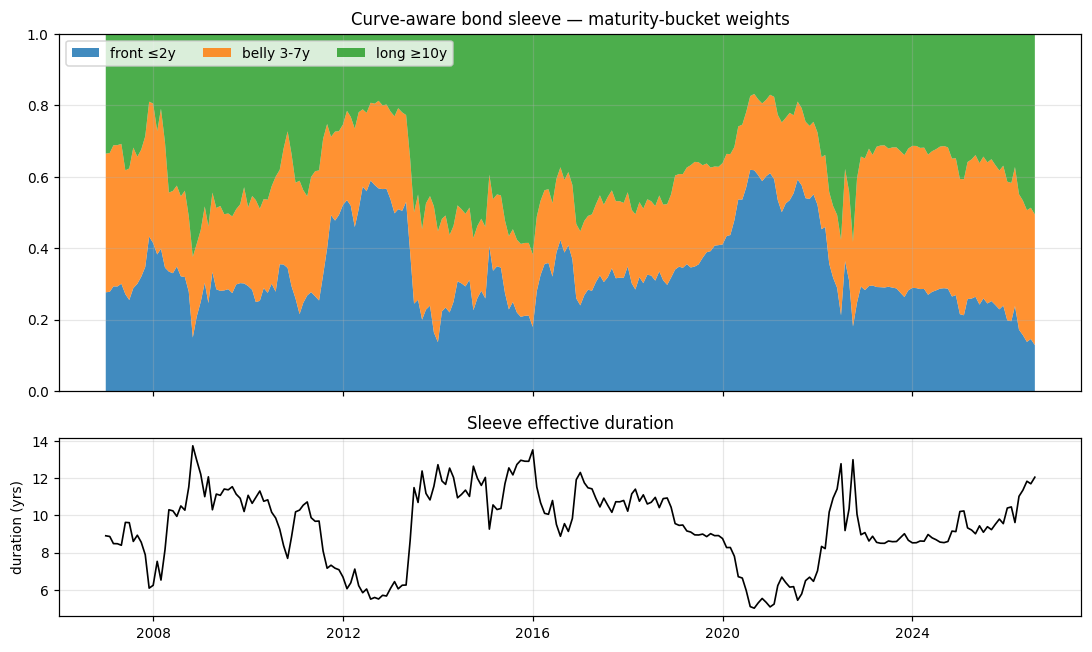

In [7]:
front_idx = [i for i, m in enumerate(MATS) if m <= 2]
belly_idx = [i for i, m in enumerate(MATS) if 2 < m <= 7]
long_idx  = [i for i, m in enumerate(MATS) if m > 7]
bret = np.column_stack([RET[:, front_idx].mean(1), RET[:, belly_idx].mean(1), RET[:, long_idx].mean(1)])
bdur = np.array([MATS[front_idx].mean(), MATS[belly_idx].mean(), MATS[long_idx].mean()])

WB = np.tile(WB0, (T, 1)).astype(float)
WB[:, 2] += A_DUR*view_dur;     WB[:, 0] -= A_DUR*view_dur            # duration: long vs front
WB[:, 0] += A_SLOPE*view_steep; WB[:, 2] -= A_SLOPE*view_steep        # steepener proxy: front vs long
WB[:, 1] += A_CURV*view_fly;    WB[:, 0] -= 0.5*A_CURV*view_fly; WB[:, 2] -= 0.5*A_CURV*view_fly
WB = np.clip(WB, 0, None); WB /= WB.sum(1, keepdims=True)
sleeve_ret = (np.roll(WB, 1, axis=0)*bret).sum(1); sleeve_ret[:1] = 0
sleeve_dur = (WB*bdur).sum(1)
sleeve = pd.Series(sleeve_ret, index=dates)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
a1.stackplot(dates, WB[:, 0], WB[:, 1], WB[:, 2],
             labels=["front ≤2y", "belly 3-7y", "long ≥10y"], alpha=0.85)
a1.set_ylim(0, 1); a1.set_title("Curve-aware bond sleeve — maturity-bucket weights")
a1.legend(loc="upper left", ncol=3); a1.margins(x=0)
a2.plot(dates, sleeve_dur, color="k", lw=1.1)
a2.set_ylabel("duration (yrs)"); a2.set_title("Sleeve effective duration")
plt.tight_layout(); plt.show()

## 7. Cross-asset allocation: V1 simple 10Y baseline vs V2 curve-native sleeve

This block now implements both Step 2 and Step 3:

- **V1 simple real-data baseline**: equity / 10Y-bond-proxy / cash allocation, where the bond signal is the 10Y yield gap vs the macro anchor.
- **V2 curve-native extension**: equity / curve-aware bond sleeve / cash allocation, where the bond leg uses level/slope/curvature views and maturity-bucket tilts.

Both versions use the same portfolio-construction layer: ERP proxy, bond/rates signal, volatility targeting, stock-bond-correlation risk, inflation throttle, rates-vol throttle, turnover and transaction costs.


CROSS-ASSET PERFORMANCE  (real data: FRED (10 real tenors) -- empirical backtest)

                           AnnRet  AnnVol  Sharpe  Sortino  MaxDD    Calmar  Turnover
Strategy V2 curve (gross)   0.089   0.079   0.896    1.132 -0.176     0.506     0.980
Strategy V2 curve (net)     0.088   0.079   0.884    1.115 -0.177     0.497     0.980
Strategy V1 10Y (net)       0.078   0.081   0.757    0.935 -0.202     0.388     0.983
Static 60/40                0.096   0.088   0.889    1.297 -0.187     0.514     0.190
Equity                      0.149   0.142   0.926    1.352 -0.239     0.622     0.000
Bonds (passive belly)       0.016   0.041  -0.031   -0.048 -0.141     0.112     0.000
Cash                        0.018   0.005     NaN      NaN -0.000 2,144.081     0.000


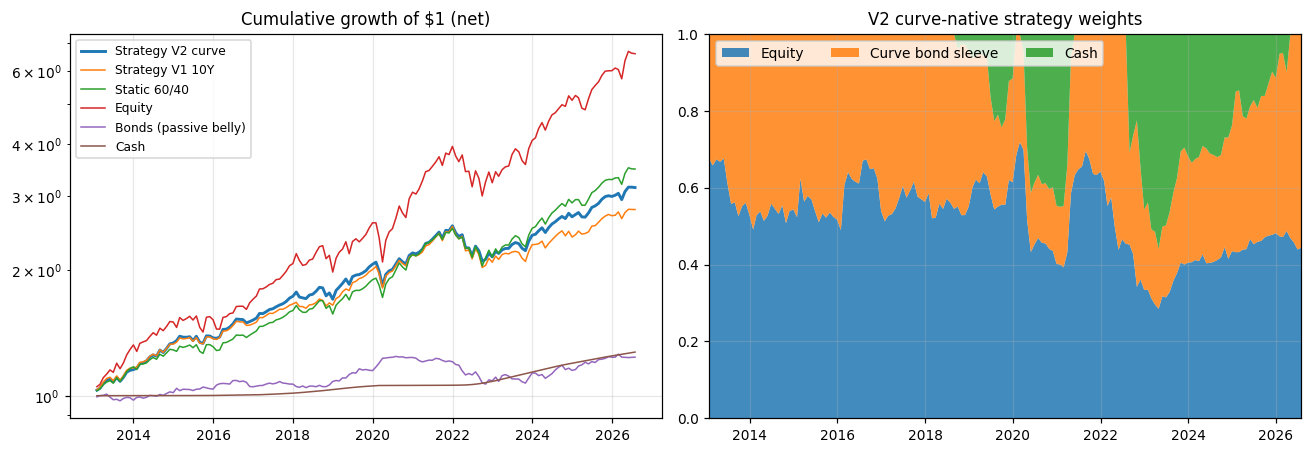

In [8]:
def backtest(W, A):                      # lag-correct, with drift + transaction costs
    n = len(W); held = np.array([0, 0, 1.0])
    g = np.full(n, np.nan); net = np.full(n, np.nan); turn = np.zeros(n); H = np.zeros((n, 3))
    for t in range(n):
        tgt = held if (t == 0 or np.any(np.isnan(W[t-1]))) else W[t-1]
        turn[t] = np.abs(tgt - held).sum()
        r = A[t]; gi = float((tgt*r).sum())
        g[t] = gi; net[t] = gi - TC*turn[t]; H[t] = tgt
        grown = tgt*(1+r); s = grown.sum(); held = grown/s if s > 0 else tgt
    return pd.DataFrame({"gross": g, "net": net, "turnover": turn, "rf": A[:, 2],
                         "we": H[:, 0], "wb": H[:, 1], "wc": H[:, 2]}, index=dates)

def metrics(bt, col="net"):
    r = bt[col].iloc[BURN:].dropna(); rfx = bt["rf"].reindex(r.index); ex = r - rfx
    ar = (1+r).prod()**(PPY/len(r)) - 1 if len(r) else np.nan
    av = r.std()*np.sqrt(PPY) if len(r) else np.nan
    esd = ex.std(); sr = ex.mean()/esd*np.sqrt(PPY) if esd and esd > 0 else np.nan
    dn = r[r < 0]; dsd = dn.std()*np.sqrt(PPY) if len(dn) > 1 else np.nan
    sortino = ex.mean()*PPY/dsd if dsd and dsd > 0 else np.nan
    cum = (1+r).cumprod(); mdd = (cum/cum.cummax()-1).min() if len(cum) else np.nan
    calmar = ar/abs(mdd) if mdd < 0 else np.nan
    return dict(AnnRet=ar, AnnVol=av, Sharpe=sr, Sortino=sortino, MaxDD=mdd,
                Calmar=calmar, Turnover=bt["turnover"].iloc[BURN:].mean()*PPY)

def make_cross_asset_weights(bond_ret_series, bond_signal, label=""):
    bond_ret_series = pd.Series(bond_ret_series, index=dates).fillna(0.0)
    z_erp_local = zscore_exp(ep - (Y[:, I10] - pi)).to_numpy()
    z_bond = zscore_exp(bond_signal).to_numpy()

    w_eq_raw = np.clip(W_EQ0 + A_EQ*np.tanh(z_erp_local), 0, None)
    w_bd_raw = np.clip(W_BD0 + A_BOND*np.tanh(z_bond), 0, None)

    vol_eq_local  = pd.Series(eq_ret, index=dates).rolling(VOL_WIN).std().to_numpy()*np.sqrt(12)
    vol_bd_local  = bond_ret_series.rolling(VOL_WIN).std().to_numpy()*np.sqrt(12)
    corr_eb_local = pd.Series(eq_ret, index=dates).rolling(CORR_WIN).corr(bond_ret_series).to_numpy()
    ratesvol_local = pd.Series(dY[:, I10], index=dates).rolling(VOL_WIN).std().to_numpy()*np.sqrt(12)
    z_rv_local = zscore_exp(ratesvol_local).to_numpy()
    infl_press_local = np.clip(pi - PI_TARGET, 0, None)

    var_p = (w_eq_raw**2*vol_eq_local**2 + w_bd_raw**2*vol_bd_local**2
             + 2*w_eq_raw*w_bd_raw*corr_eb_local*vol_eq_local*vol_bd_local)
    vol_p = np.sqrt(np.clip(var_p, 1e-8, None))
    m = np.clip(VOL_TARGET/vol_p, None, M_MAX)
    throttle = 1/(1 + B_INFL*infl_press_local + C_RV*np.clip(z_rv_local, 0, None))
    w_eq = np.clip(m*throttle*w_eq_raw, 0, W_MAX)
    w_bd = np.clip(m*throttle*w_bd_raw, 0, W_MAX)
    tot = w_eq + w_bd; sc = np.where(tot > 1, 1/tot, 1); w_eq *= sc; w_bd *= sc
    w_cash = 1 - w_eq - w_bd
    W3 = np.column_stack([w_eq, w_bd, w_cash])
    valid = ~np.isnan(np.column_stack([z_erp_local, z_bond, vol_eq_local, vol_bd_local, corr_eb_local])).any(1)
    W3[~valid] = np.nan
    aux = dict(z_erp=z_erp_local, z_bond=z_bond, vol_eq=vol_eq_local, vol_bd=vol_bd_local,
               corr_eb=corr_eb_local, ratesvol=ratesvol_local, z_rv=z_rv_local,
               infl_press=infl_press_local)
    return W3, aux

# V1: simple Step-2 baseline — 10Y proxy around macro anchor.
simple_bond = pd.Series(RET[:, I10], index=dates, name="10Y proxy")
gap_10y = Y[:, I10] - b0_anchor
W3_v1, aux_v1 = make_cross_asset_weights(simple_bond, gap_10y, label="V1 10Y")
strat_v1 = backtest(W3_v1, np.column_stack([eq_ret, simple_bond.to_numpy(), rf]))

# V2/V3: rates-native curve sleeve from the PCA views.
W3, aux_v2 = make_cross_asset_weights(sleeve, gap_F[:, 0], label="V2 curve sleeve")
strat = backtest(W3, np.column_stack([eq_ret, sleeve.to_numpy(), rf]))

# Expose V2 diagnostics for the next section.
z_erp, z_gap_lvl = aux_v2["z_erp"], aux_v2["z_bond"]
vol_eq, vol_bd, corr_eb = aux_v2["vol_eq"], aux_v2["vol_bd"], aux_v2["corr_eb"]
ratesvol, z_rv, infl_press = aux_v2["ratesvol"], aux_v2["z_rv"], aux_v2["infl_press"]

belly_passive = bret[:, 1]               # clean passive-bond benchmark (constant belly)
def static(we, wb, bond):
    return backtest(np.tile([we, wb, 1-we-wb], (T, 1)), np.column_stack([eq_ret, bond, rf]))
bench = {"Static 60/40": static(0.6, 0.4, belly_passive), "Equity": static(1, 0, belly_passive),
         "Bonds (passive belly)": static(0, 1, belly_passive),  "Cash": static(0, 0, belly_passive)}

tbl = pd.DataFrame({"Strategy V2 curve (gross)": metrics(strat, "gross"),
                    "Strategy V2 curve (net)":   metrics(strat, "net"),
                    "Strategy V1 10Y (net)":     metrics(strat_v1, "net"),
                    **{k: metrics(v) for k, v in bench.items()}}).T
print(f"CROSS-ASSET PERFORMANCE  ({DATA_LABEL} -- {RESULT_NOTE})\n")
print(tbl.to_string())

start = dates[BURN]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for nm, bt in {"Strategy V2 curve": strat, "Strategy V1 10Y": strat_v1, **bench}.items():
    cum = (1+bt["net"].loc[start:]).cumprod()
    ax[0].plot(cum.index, cum.values, lw=1.9 if nm == "Strategy V2 curve" else 1.0, label=nm)
ax[0].set_yscale("log"); ax[0].set_title("Cumulative growth of $1 (net)"); ax[0].legend(fontsize=8)
ww = strat.loc[start:, ["we", "wb", "wc"]]
ax[1].stackplot(ww.index, ww["we"], ww["wb"], ww["wc"],
                labels=["Equity", "Curve bond sleeve", "Cash"], alpha=0.85)
ax[1].set_ylim(0, 1); ax[1].set_title("V2 curve-native strategy weights"); ax[1].legend(loc="upper left", ncol=3)
ax[1].margins(x=0); plt.tight_layout(); plt.show()


## Turnover reduction — no-trade band & weight smoothing (V2 strategy)

V2 matched a static 60/40 on Sharpe but at **~5× the turnover**, with the cost drag
modelled small — so the tie is *fragile to higher transaction costs*. This section applies
two standard turnover-reduction levers to the V2 weight matrix `W3` and sweeps them:

- a **no-trade band** — only rebalance a leg when its desired move exceeds the band;
- **EWMA weight smoothing** — slow the target path with $\tilde w_t=(1-\lambda)\tilde w_{t-1}+\lambda w_t^{\text{target}}$.

It **reuses this notebook's own `backtest` / `metrics`** (apples-to-apples with the table
above) and plots the **turnover–Sharpe frontier** at base / 25bp / 50bp costs, with the
static-60/40 turnover marked as the target to approach. The signature result to look for:
at realistic costs the net-Sharpe optimum sits at a **non-zero band** — trading less
actually improves net performance once costs bite. Pick the band whose net Sharpe at your
assumed cost is maximal while turnover moves toward the 60/40 level.

In [9]:
# ---- Turnover reduction on the V2 weights: no-trade band ----
A_v2 = np.column_stack([eq_ret, sleeve.to_numpy(), rf])

def backtest_band(W, A, band=0.0):
    """Same lag-correct engine as backtest(), but a leg trades only if its
    desired move exceeds `band` (a no-trade region around the drifted holding)."""
    n = len(W); held = np.array([0, 0, 1.0])
    g = np.full(n, np.nan); turn = np.zeros(n); H = np.zeros((n, 3))
    for t in range(n):
        if t == 0 or np.any(np.isnan(W[t-1])):
            tgt = held
        else:
            move = W[t-1] - held
            trade = np.where(np.abs(move) > band, move, 0.0)
            tgt = held + trade; tgt = np.clip(tgt, 0, None)
            s = tgt.sum(); tgt = tgt/s if s > 0 else held
        turn[t] = np.abs(tgt - held).sum(); r = A[t]; gi = float((tgt*r).sum())
        g[t] = gi; H[t] = tgt; grown = tgt*(1+r); s = grown.sum(); held = grown/s if s > 0 else tgt
    return pd.DataFrame({"gross": g, "net": g - TC*turn, "turnover": turn,
                         "rf": A[:, 2], "we": H[:, 0], "wb": H[:, 1], "wc": H[:, 2]}, index=dates)

def sharpe_at(bt, tc):
    """Net Sharpe at an arbitrary transaction-cost level (gross - tc*turnover)."""
    r = (bt["gross"] - tc*bt["turnover"]).iloc[BURN:].dropna()
    ex = r - bt["rf"].reindex(r.index); sd = ex.std()
    return ex.mean()/sd*np.sqrt(PPY) if sd and sd > 0 else np.nan

bench_turn = metrics(bench["Static 60/40"])["Turnover"]
bands = [0.0, 0.0025, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.12]
rows = []
for bd in bands:
    bt = backtest_band(W3, A_v2, bd); m = metrics(bt, "net")
    rows.append({"band": bd, "AnnTurnover": m["Turnover"], "Sharpe_net": m["Sharpe"],
                 "MaxDD": m["MaxDD"], "Sharpe@25bp": sharpe_at(bt, 0.0025),
                 "Sharpe@50bp": sharpe_at(bt, 0.0050)})
band_tbl = pd.DataFrame(rows).set_index("band")
print(f"NO-TRADE BAND SWEEP on V2 weights  ({DATA_LABEL})")
print(f"(baseline V2 turnover {band_tbl.loc[0.0,'AnnTurnover']:.3f}  |  static 60/40 turnover {bench_turn:.3f})\n")
print(band_tbl.to_string())


NO-TRADE BAND SWEEP on V2 weights  (real data: FRED (10 real tenors))
(baseline V2 turnover 0.980  |  static 60/40 turnover 0.190)

       AnnTurnover  Sharpe_net  MaxDD  Sharpe@25bp  Sharpe@50bp
band                                                           
0.000        0.980       0.884 -0.177        0.865        0.834
0.003        0.978       0.884 -0.177        0.865        0.835
0.005        0.973       0.885 -0.177        0.866        0.836
0.010        0.956       0.885 -0.178        0.866        0.836
0.020        0.889       0.885 -0.178        0.868        0.840
0.030        0.787       0.886 -0.178        0.871        0.847
0.050        0.692       0.885 -0.180        0.872        0.851
0.080        0.575       0.905 -0.173        0.895        0.878
0.120        0.433       0.855 -0.170        0.847        0.834


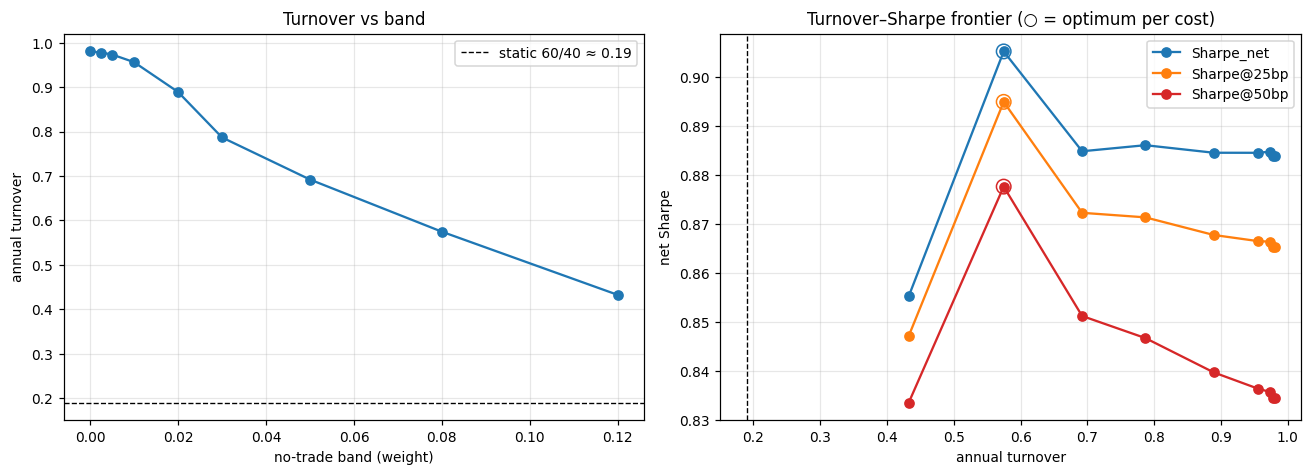

TC base TC: best band 0.0800 -> net Sharpe 0.905 (vs 0.884 at band 0)  |  turnover 0.57 vs 0.98
TC    25bp: best band 0.0800 -> net Sharpe 0.895 (vs 0.865 at band 0)  |  turnover 0.57 vs 0.98
TC    50bp: best band 0.0800 -> net Sharpe 0.878 (vs 0.834 at band 0)  |  turnover 0.57 vs 0.98


In [10]:
# ---- Turnover-Sharpe frontier at several cost levels ----
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
a1.plot(band_tbl.index, band_tbl["AnnTurnover"], marker="o")
a1.axhline(bench_turn, color="k", ls="--", lw=0.9, label=f"static 60/40 \u2248 {bench_turn:.2f}")
a1.set_xlabel("no-trade band (weight)"); a1.set_ylabel("annual turnover")
a1.set_title("Turnover vs band"); a1.legend()
for col, c in [("Sharpe_net", "C0"), ("Sharpe@25bp", "C1"), ("Sharpe@50bp", "C3")]:
    a2.plot(band_tbl["AnnTurnover"], band_tbl[col], marker="o", color=c, label=col)
    k = band_tbl[col].idxmax()
    a2.scatter([band_tbl.loc[k, "AnnTurnover"]], [band_tbl.loc[k, col]],
               s=90, facecolors="none", edgecolors=c, zorder=5)
a2.axvline(bench_turn, color="k", ls="--", lw=0.9)
a2.set_xlabel("annual turnover"); a2.set_ylabel("net Sharpe")
a2.set_title("Turnover\u2013Sharpe frontier (\u25cb = optimum per cost)"); a2.legend()
plt.tight_layout(); plt.show()

for lab, col in [("base TC", "Sharpe_net"), ("25bp", "Sharpe@25bp"), ("50bp", "Sharpe@50bp")]:
    k = band_tbl[col].idxmax()
    print(f"TC {lab:>7}: best band {k:.4f} -> net Sharpe {band_tbl.loc[k, col]:.3f} "
          f"(vs {band_tbl.loc[0.0, col]:.3f} at band 0)  |  turnover "
          f"{band_tbl.loc[k, 'AnnTurnover']:.2f} vs {band_tbl.loc[0.0, 'AnnTurnover']:.2f}")


WEIGHT-SMOOTHING SWEEP on V2 weights

        AnnTurnover  Sharpe_net  Sharpe@50bp
lambda                                      
1.000         0.980       0.884        0.834
0.600         0.701       0.881        0.847
0.400         0.576       0.878        0.849
0.250         0.477       0.877        0.853
0.150         0.388       0.884        0.865
0.100         0.330       0.894        0.878
0.060         0.276       0.902        0.889


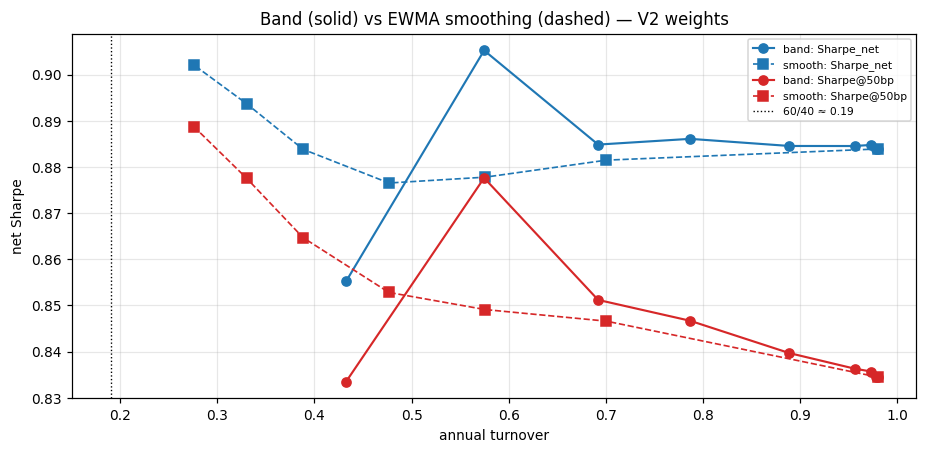

In [11]:
# ---- Alternative lever: EWMA smoothing of the target weights ----
def smooth_targets(W, lam):
    Ws = W.copy()
    for t in range(1, len(W)):
        if np.any(np.isnan(W[t])):           Ws[t] = Ws[t-1]
        elif np.any(np.isnan(Ws[t-1])):      Ws[t] = W[t]
        else:                                Ws[t] = (1-lam)*Ws[t-1] + lam*W[t]
    s = Ws.sum(1, keepdims=True); return np.where(s > 0, Ws/s, Ws)

lams = [1.0, 0.6, 0.4, 0.25, 0.15, 0.10, 0.06]
rows = []
for lam in lams:
    bt = backtest_band(smooth_targets(W3, lam), A_v2, 0.0); m = metrics(bt, "net")
    rows.append({"lambda": lam, "AnnTurnover": m["Turnover"], "Sharpe_net": m["Sharpe"],
                 "Sharpe@50bp": sharpe_at(bt, 0.0050)})
sm_tbl = pd.DataFrame(rows).set_index("lambda")
print("WEIGHT-SMOOTHING SWEEP on V2 weights\n"); print(sm_tbl.to_string())

plt.figure(figsize=(8.5, 4.2))
for col, c in [("Sharpe_net", "C0"), ("Sharpe@50bp", "C3")]:
    plt.plot(band_tbl["AnnTurnover"], band_tbl[col], marker="o", color=c, lw=1.4, label=f"band: {col}")
    plt.plot(sm_tbl["AnnTurnover"], sm_tbl[col], marker="s", color=c, ls="--", lw=1.1, label=f"smooth: {col}")
plt.axvline(bench_turn, color="k", ls=":", lw=0.9, label=f"60/40 \u2248 {bench_turn:.2f}")
plt.xlabel("annual turnover"); plt.ylabel("net Sharpe")
plt.title("Band (solid) vs EWMA smoothing (dashed) \u2014 V2 weights"); plt.legend(fontsize=7)
plt.tight_layout(); plt.show()


## 8. Stock-bond correlation & regime diagnostics

The trailing stock-bond correlation is consumed by the risk-targeting layer. In synthetic mode, it is deliberately designed to flip with inflation. In real-data mode, this becomes a diagnostic of whether the model de-risks when the equity/bond hedge becomes less reliable.


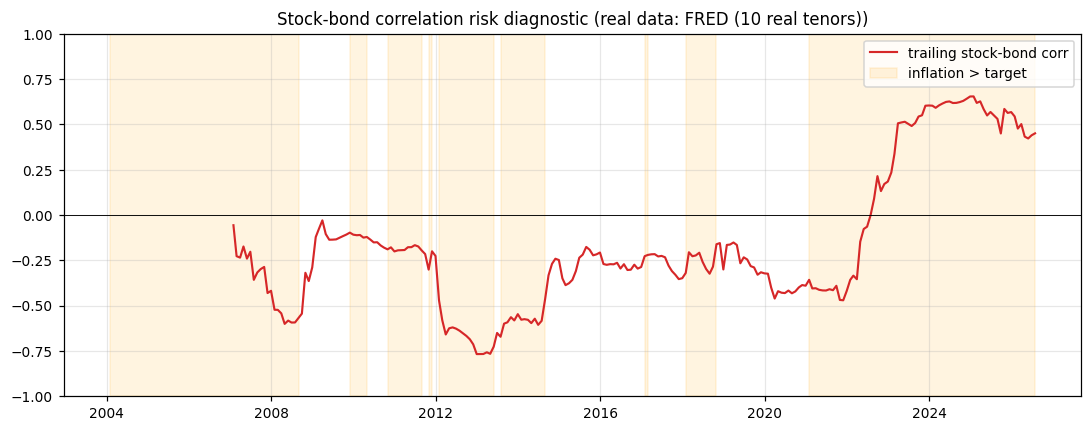

REGIME BREAKDOWN  (V2 curve strategy net excess return, annualised; real data: FRED (10 real tenors))

                             AnnExcess  TimeShare
Inflation > target               0.060      0.601
Inflation <= target              0.085      0.399
Stock-bond corr > 0              0.039      0.294
Stock-bond corr < 0              0.083      0.706
Level gap > 0 (yields rich)      0.061      0.620
Level gap < 0                    0.085      0.380


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, corr_eb, color="C3", lw=1.4, label="trailing stock-bond corr")
ax.axhline(0, color="k", lw=0.6)
ax.fill_between(dates, -1, 1, where=(pi > PI_TARGET), color="orange", alpha=0.12, label="inflation > target")
ax.set_ylim(-1, 1); ax.set_title(f"Stock-bond correlation risk diagnostic ({DATA_LABEL})"); ax.legend()
plt.tight_layout(); plt.show()

ex = (strat["net"] - strat["rf"]).iloc[BURN:]
reg = {"Inflation > target": pi > PI_TARGET, "Inflation <= target": pi <= PI_TARGET,
       "Stock-bond corr > 0": corr_eb > 0, "Stock-bond corr < 0": corr_eb <= 0,
       "Level gap > 0 (yields rich)": gap_F[:, 0] > 0, "Level gap < 0": gap_F[:, 0] <= 0}
rows = {}
for nm, mk in reg.items():
    msk = pd.Series(mk, index=dates).reindex(ex.index).fillna(False)
    sub = ex[msk]
    rows[nm] = {"AnnExcess": sub.mean()*PPY if len(sub) else np.nan, "TimeShare": len(sub)/len(ex)}
print(f"REGIME BREAKDOWN  (V2 curve strategy net excess return, annualised; {DATA_LABEL})\n")
print(pd.DataFrame(rows).T.to_string())


## Limitations and next extensions

### Synthetic mode
Synthetic data embeds the targeted effects. Sharpe ratios in synthetic mode are **mechanics checks**, not evidence of real alpha.

### Real-data mode
Real-data mode is more informative but still proxy-based:

- Treasury constant-maturity yield returns are duration/convexity approximations, not tradable bond-index returns.
- The equity leg is a SPY/S&P 500 proxy; if `yfinance` is unavailable, it falls back to FRED price returns.
- The ERP proxy is intentionally simple: cash-flow yield minus real yield. If trailing dividends are unavailable, it falls back to a constant E/P proxy, so the signal mainly comes from real-rate variation.
- Inflation expectations are proxied by 10Y breakevens (`T10YIE`), not a full point-in-time inflation-expectations curve.
- The macro anchor is deliberately parsimonious: `r* proxy + breakeven inflation + assumed term premium`.

### What this version adds

1. `USE_REAL_DATA` toggle.
2. Real-data V1 baseline: simple 10Y macro-anchor equity/bond/cash TAA.
3. Real-data V2/V3 curve-native version: yield-curve PCA, factor gaps, maturity-bucket bond sleeve.
4. Direct comparison between V1 simple 10Y allocation and V2 curve-native allocation.

### Natural next step

Add a scenario engine around the realised weights:

- VAR/OU/residual-bootstrap scenarios on equity returns and curve factors;
- portfolio VaR / ES / conditional drawdown;
- regime-conditioned stress tests;
- ablation tests: no macro anchor, no curve PCA, no inflation throttle, no stock-bond-correlation scaling, no carry/rolldown.


## V3 — Scenario engine on the real curve factors

The roadmap **V3 (scenario / tail engine)**, wired to the **real** curve produced above:
a **VAR(1) / discrete OU** fit to the real `[Level, Slope, Curv, equity-excess]` state,
Monte-Carlo + a **stationary block bootstrap** → horizon **VaR / ES** and **conditional
drawdown** on the current weights, **regime-conditioned stress tests**, and a
**walk-forward Kupiec VaR backtest**. Self-contained (recomputes its own PCA loadings from
`Y`, reads current weights from `W3`); no synthetic fallback. No-look-ahead: the Kupiec
backtest uses past-only windows (the forward VAR fit is full-sample for illustration).

REAL VAR(1) eigenvalue moduli: [0.976 0.976 0.893 0.01 ] | half-lives (months): [28.3 28.3  6.1  0.2]
shock corr Level<->EqExcess: 0.12  (negative => bonds hedge equities)

12-month forward P&L risk on the REAL current book (fraction of NAV):

                      Mean   Vol  VaR95  ES95  VaR99  ES99
VAR/OU (structural)  0.090 0.082  0.040 0.070  0.089 0.114
Stationary bootstrap 0.086 0.076  0.049 0.104  0.142 0.176

Conditional drawdown over 12m path: VAR/OU CDaR95 -0.111 | bootstrap CDaR95 -0.153


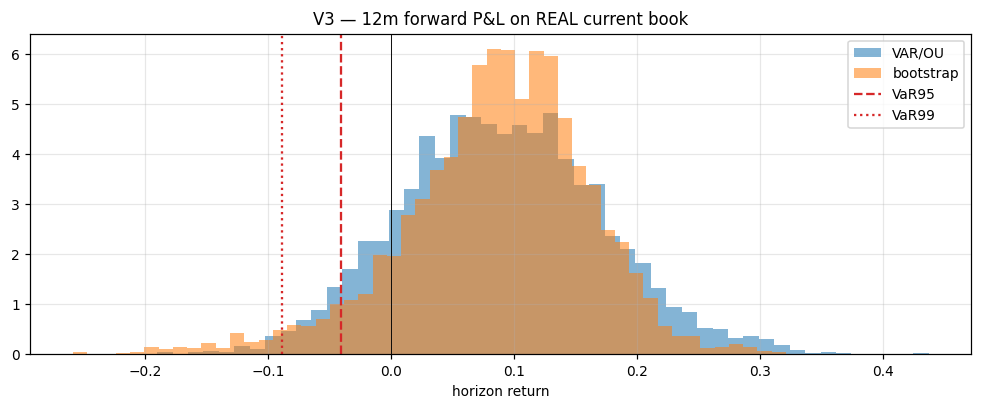

In [13]:
# ===== V3 — scenario engine on the REAL curve factors =====
import matplotlib.pyplot as plt
def _pca_load(Yb):
    Sg=np.cov(np.diff(Yb,axis=0),rowvar=False); va,ve=np.linalg.eigh(Sg); o=np.argsort(va)[::-1]
    Bl=ve[:,o][:,:3].copy()
    if Bl[:,0].mean()<0: Bl[:,0]*=-1
    if Bl[-1,1]-Bl[0,1]<0: Bl[:,1]*=-1
    if Bl[len(Bl)//2,2]<0: Bl[:,2]*=-1
    return Bl
Bv3=_pca_load(Y[:BURN]); muYv3=Y[:BURN].mean(0); Fv3=(Y-muYv3)@Bv3
eq_excess=np.asarray(eq_ret,float)-np.asarray(rf,float)
St=np.column_stack([Fv3[:,0],Fv3[:,1],Fv3[:,2],eq_excess]); fin=np.isfinite(St).all(1); Sf=St[fin]

def _fit_var1(M):
    X=np.column_stack([np.ones(len(M)-1),M[:-1]]); Yt=M[1:]; co=np.linalg.lstsq(X,Yt,rcond=None)[0]
    return co[0],co[1:].T,np.cov((Yt-X@co),rowvar=False)
cV,AV,Cov=_fit_var1(Sf)
ev=np.abs(np.linalg.eig(AV)[0]); hl=np.where(ev<1,-np.log(2)/np.log(np.clip(ev,1e-6,0.999)),np.inf)
sd=np.sqrt(np.diag(Cov))
print("REAL VAR(1) eigenvalue moduli:",np.round(np.sort(ev)[::-1],3),"| half-lives (months):",np.round(np.sort(hl)[::-1],1))
print("shock corr Level<->EqExcess: %.2f  (negative => bonds hedge equities)"%(Cov[0,3]/(sd[0]*sd[3])))

fr=[i for i,m in enumerate(MATS) if m<=2]; be=[i for i,m in enumerate(MATS) if 2<m<=7]; lg=[i for i,m in enumerate(MATS) if m>7]
WBc=(WB[-1] if 'WB' in globals() and np.all(np.isfinite(WB[-1])) else np.array([0.30,0.30,0.40]))
_wf=np.where(np.isfinite(W3).all(1))[0]; _wc=(W3[_wf[-1]] if len(_wf) else np.array([0.5,0.4,0.1]))
we_c,wb_c,wc_c=float(_wc[0]),float(_wc[1]),float(_wc[2]); rf_c=float(np.asarray(rf)[-1])
Dd=MATS.astype(float); Cc=MATS**2; h=1/12; s0=Sf[-1].copy(); L=np.linalg.cholesky(Cov+1e-12*np.eye(4))
H,N,BLK=12,4000,6; _rng=np.random.default_rng(0)
def _sim_var(n):
    P=np.zeros((n,H,4)); s=np.tile(s0,(n,1))
    for t in range(H): s=cV+s@AV.T+_rng.standard_normal((n,4))@L.T; P[:,t]=s
    return P
def _revalue(P):
    n=len(P); port=np.zeros((n,H))
    for i in range(n):
        Yp=muYv3[None,:]+P[i,:,:3]@Bv3.T; Yprev=np.vstack([Y[-1],Yp[:-1]]); dy=Yp-Yprev
        for t in range(H):
            yr=np.interp(MATS-h,MATS,Yprev[t]); rs=Yprev[t]/12+Dd*(Yprev[t]-yr)-Dd*dy[t]+0.5*Cc*dy[t]**2
            bk=np.array([rs[fr].mean(),rs[be].mean(),rs[lg].mean()]); port[i,t]=we_c*(rf_c+P[i,t,3])+wb_c*(bk@WBc)+wc_c*rf_c
    return port
binp_full=np.column_stack([bret,eq_excess]); keep=np.isfinite(binp_full).all(1); keep[:BURN]=False; binp=binp_full[keep]
def _sim_boot(n):
    Lh=len(binp); port=np.zeros((n,H))
    for i in range(n):
        t=0
        while t<H:
            idx=_rng.integers(0,Lh)
            while t<H:
                row=binp[idx]; port[i,t]=we_c*(rf_c+row[3])+wb_c*(WBc@row[:3])+wc_c*rf_c; t+=1
                if _rng.random()<1/BLK: break
                idx=(idx+1)%Lh
    return port
pv=_revalue(_sim_var(N)); pb=_sim_boot(N)
def _term(p): cum=np.cumprod(1+p,axis=1); return cum[:,-1]-1,(cum/np.maximum.accumulate(cum,axis=1)-1).min(1)
tv,ddv=_term(pv); tb,ddb=_term(pb)
def _risk(p): return dict(Mean=p.mean(),Vol=p.std(),VaR95=-np.percentile(p,5),ES95=-p[p<=np.percentile(p,5)].mean(),VaR99=-np.percentile(p,1),ES99=-p[p<=np.percentile(p,1)].mean())
print("\n%d-month forward P&L risk on the REAL current book (fraction of NAV):\n"%H)
print(pd.DataFrame({"VAR/OU (structural)":_risk(tv),"Stationary bootstrap":_risk(tb)}).T.to_string())
print("\nConditional drawdown over %dm path: VAR/OU CDaR95 %.3f | bootstrap CDaR95 %.3f"%(H,ddv[ddv<=np.percentile(ddv,5)].mean(),ddb[ddb<=np.percentile(ddb,5)].mean()))
plt.figure(figsize=(9,3.8))
plt.hist(tv,bins=50,alpha=0.55,density=True,label="VAR/OU"); plt.hist(tb,bins=50,alpha=0.55,density=True,label="bootstrap")
plt.axvline(np.percentile(tv,5),color="C3",ls="--",label="VaR95"); plt.axvline(np.percentile(tv,1),color="C3",ls=":",label="VaR99")
plt.axvline(0,color="k",lw=0.6); plt.title(f"V3 — {H}m forward P&L on REAL current book"); plt.xlabel("horizon return"); plt.legend(); plt.tight_layout(); plt.show()


In [14]:
# regime-conditioned stress tests on the REAL current weights
def _stress(dl,ds,dc,deq):
    df=np.array([dl,ds,dc]); dy=Bv3@df; yr=np.interp(MATS-h,MATS,Y[-1]); rs=Y[-1]/12+Dd*(Y[-1]-yr)-Dd*dy+0.5*Cc*dy**2
    bk=np.array([rs[fr].mean(),rs[be].mean(),rs[lg].mean()]); return we_c*(rf_c+deq)+wb_c*(bk@WBc)+wc_c*rf_c
SC={"2022 inflation surge (bear-flatten,+lvl,eq -15%)":(0.015,-0.010,0,-0.15),
    "Growth/recession (-lvl, eq -20%)":(-0.010,0.004,0,-0.20),
    "Bear steepener (+slope, eq -5%)":(0.005,0.012,0,-0.05),
    "Parallel +200bp (eq -10%)":(0.020,0,0,-0.10)}
print("Stress P&L on REAL current weights  eq/bd/cash = %.2f/%.2f/%.2f:\n"%(we_c,wb_c,wc_c))
print(pd.DataFrame({k:{"Portfolio P&L":_stress(*v)} for k,v in SC.items()}).T.to_string())

# Kupiec VaR backtest: equity-excess leg (volatile, validates coverage) + strategy net
from statistics import NormalDist
def _kupiec(exc,n,p):
    x=int(exc.sum())
    if x==0 or x==n: return x,x/n,np.nan
    pi=x/n; LR=-2*((n-x)*np.log(1-p)+x*np.log(p)-((n-x)*np.log(1-pi)+x*np.log(pi))); return x,pi,LR
strat_net=strat["net"].to_numpy(); tests={"Equity excess":eq_excess,"Strategy net":strat_net}
START=max(60,BURN)
print("\nWalk-forward VaR backtest (Kupiec POF):")
for nm,ser in tests.items():
    s=np.asarray(ser,float); nT=len(s)
    for p in [0.05,0.01]:
        eh=np.zeros(nT,bool)
        for t in range(START,nT):
            hist=s[:t]; hist=hist[np.isfinite(hist)]
            if len(hist)>20 and np.isfinite(s[t]): eh[t]=s[t]<np.percentile(hist,100*p)
        no=nT-START; x,ph,lr=_kupiec(eh[START:],no,p)
        flag="" if not np.isfinite(lr) else ("(reject)" if lr>3.84 else "(ok)")
        print(f"  [{nm}] {int((1-p)*100)}% VaR: {x:>3} exc ({ph:.2%}) Kupiec LR {lr:5.2f} {flag}   (nominal {p:.0%})")


Stress P&L on REAL current weights  eq/bd/cash = 0.43/0.57/0.00:

                                                  Portfolio P&L
2022 inflation surge (bear-flatten,+lvl,eq -15%)         -0.074
Growth/recession (-lvl, eq -20%)                         -0.068
Bear steepener (+slope, eq -5%)                          -0.051
Parallel +200bp (eq -10%)                                -0.081

Walk-forward VaR backtest (Kupiec POF):
  [Equity excess] 95% VaR:   7 exc (4.29%) Kupiec LR  0.18 (ok)   (nominal 5%)
  [Equity excess] 99% VaR:   1 exc (0.61%) Kupiec LR  0.29 (ok)   (nominal 1%)
  [Strategy net] 95% VaR:   8 exc (4.91%) Kupiec LR  0.00 (ok)   (nominal 5%)
  [Strategy net] 99% VaR:   2 exc (1.23%) Kupiec LR  0.08 (ok)   (nominal 1%)


## V4 — Cross-currency / global macro on real FX & rates (G10 carry cross-section)

The roadmap **V4**, wired to **real FRED data** across a proper **G10 carry cross-section**
— high-yielders (AUD, NZD, NOK) vs funders (JPY, CHF, EUR) so there is real yield
dispersion. FX spot (`DEXUS**` / `DEX**US`) and foreign 3-month interbank rates
(`IR3TIB01*`), with a `VIXCLS` funding-stress proxy; the fetch is **per-series robust** (a
missing ticker drops only that currency).

The signal is the textbook **carry factor**: cross-sectionally **long high-carry, short
low-carry, dollar-neutral** — naive vs a **risk-managed** version (inverse-FX-vol sizing, a
funding-stress throttle, drawdown control). Then the carry-vs-next-FX-move scatter (UIP
failure) and the risk-managed factor added as a sleeve to the V2 book.

**Honesty.** The **carry factor is real evidence**; the **covered-basis (CIP) leg is not
computed** (the published cross-currency basis isn't free on FRED — it needs a Bloomberg/
BIS series in the same wrapper; the cell says so loudly). If too few currencies are
available V4 skips cleanly rather than inventing data.

In [15]:
# ===== V4 — cross-currency / global macro on REAL FRED data (G10 carry cross-section) =====
# vs USD; high-yielders (AUD/NOK/NZD) vs funders (JPY/CHF/EUR) -> real yield dispersion.
UNIV={ "EUR":("DEXUSEU",False,"IR3TIB01EZM156N"),
       "JPY":("DEXJPUS",True ,"IR3TIB01JPM156N"),
       "GBP":("DEXUSUK",False,"IR3TIB01GBM156N"),
       "AUD":("DEXUSAL",False,"IR3TIB01AUM156N"),
       "CAD":("DEXCAUS",True ,"IR3TIB01CAM156N"),
       "CHF":("DEXSZUS",True ,"IR3TIB01CHM156N"),
       "NOK":("DEXNOUS",True ,"IR3TIB01NOM156N"),
       "SEK":("DEXSDUS",True ,"IR3TIB01SEM156N"),
       "NZD":("DEXUSNZ",False,"IR3TIB01NZM156N") }
START_FX=str(pd.Timestamp(dates[0]).date()); END_FX=str(pd.Timestamp(dates[-1]).date())
def _fred1(sid):
    try:
        d=fred_series([sid],START_FX,END_FX); return d[sid] if (d is not None and sid in d.columns) else None
    except Exception as e:
        warnings.warn(f"V4 fetch failed {sid}: {e}"); return None
S_for={}; r_for={}
for c,(fxid,inv,rid) in UNIV.items():
    fx=_fred1(fxid); rr=_fred1(rid)
    if fx is None or rr is None:
        warnings.warn(f"V4: dropping {c} (missing FX or rate)"); continue
    fxm=fx.resample("ME").last().reindex(dates).ffill()
    S_for[c]=(1.0/fxm).to_numpy() if inv else fxm.to_numpy()
    r_for[c]=(rr.resample("ME").last().reindex(dates).ffill()/100.0).to_numpy()
vix_raw=_fred1("VIXCLS")
CCY=[c for c in UNIV if c in S_for and c in r_for]
ok_v4=len(CCY)>=4
if not ok_v4:
    _loud(f"V4: only {len(CCY)} currencies available -> section skipped (need >=4).")

if ok_v4:
    r_usd_v4=np.asarray(rf,float)*12.0
    carry={}; xret={}
    for c in CCY:
        dlnS=np.concatenate([[0],np.diff(np.log(S_for[c]))])
        carry[c]=r_for[c]-r_usd_v4; xret[c]=np.roll(carry[c],1)/12+dlnS; xret[c][0]=0
    X=pd.DataFrame(xret,index=dates); CAR=pd.DataFrame(carry,index=dates)
    # ---- cross-sectional carry FACTOR: long high-carry, short low-carry, dollar-neutral ----
    dem=CAR.sub(CAR.mean(axis=1),axis=0)
    w_ns=dem.div(dem.abs().sum(axis=1).replace(0,np.nan),axis=0).fillna(0)
    naive=(w_ns.shift(1)*X).sum(axis=1)
    fxvol=X.rolling(12).std()*np.sqrt(12); invv=(1/fxvol).replace([np.inf,-np.inf],np.nan)
    wr=dem*invv; wr=wr.sub(wr.mean(axis=1),axis=0); wr=wr.div(wr.abs().sum(axis=1).replace(0,np.nan),axis=0).fillna(0)
    if vix_raw is not None:
        vx=vix_raw.resample("ME").last().reindex(dates).ffill(); stressV=(vx/vx.rolling(36,min_periods=12).median()-1).clip(lower=0).fillna(0)
    else:
        sx=X.std(axis=1); stressV=(sx.rolling(6).mean()/sx.rolling(36,min_periods=12).median()-1).clip(lower=0).fillna(0)
    grossT=1/(1+3.0*stressV); base=(wr.shift(1)*X).sum(axis=1)
    eqc=(1+base.fillna(0)).cumprod(); ddc=eqc/eqc.cummax()-1; ddm=(1+2.5*ddc).clip(0.3,1.0)
    rm=(wr.shift(1)*X).sum(axis=1)*grossT*ddm
    def _stx(r):
        r=r.dropna()
        if len(r)<24 or r.std()==0: return {"AnnRet":np.nan,"AnnVol":np.nan,"Sharpe":np.nan,"MaxDD":np.nan}
        ar=(1+r).prod()**(12/len(r))-1; cum=(1+r).cumprod()
        return {"AnnRet":ar,"AnnVol":r.std()*np.sqrt(12),"Sharpe":r.mean()/r.std()*np.sqrt(12),"MaxDD":(cum/cum.cummax()-1).min()}
    print(f"REAL FX CARRY FACTOR (long-short, dollar-neutral) — {len(CCY)} ccy: {', '.join(CCY)}\n")
    print(pd.DataFrame({"Naive carry":_stx(naive),"Risk-managed carry":_stx(rm)}).T.to_string())
    print("\nMean carry by ccy (ann.):",{c:round(float(CAR[c].mean()),4) for c in sorted(CCY,key=lambda k:-CAR[k].mean())})
    hi=stressV>stressV.quantile(0.8)
    print("Carry calm vs stress (ann.): naive %.3f / %.3f | risk-managed %.3f / %.3f"%(
        naive[~hi].mean()*12,naive[hi].mean()*12,rm[~hi].mean()*12,rm[hi].mean()*12))


REAL FX CARRY FACTOR (long-short, dollar-neutral) — 9 ccy: EUR, JPY, GBP, AUD, CAD, CHF, NOK, SEK, NZD

                    AnnRet  AnnVol  Sharpe  MaxDD
Naive carry          0.010   0.038   0.269 -0.168
Risk-managed carry   0.016   0.025   0.646 -0.047

Mean carry by ccy (ann.): {'NZD': 0.02, 'AUD': 0.0173, 'NOK': 0.0078, 'GBP': 0.0055, 'CAD': 0.0004, 'EUR': -0.0046, 'SEK': -0.0057, 'JPY': -0.0148, 'CHF': -0.0157}
Carry calm vs stress (ann.): naive 0.029 / -0.065 | risk-managed 0.024 / -0.015


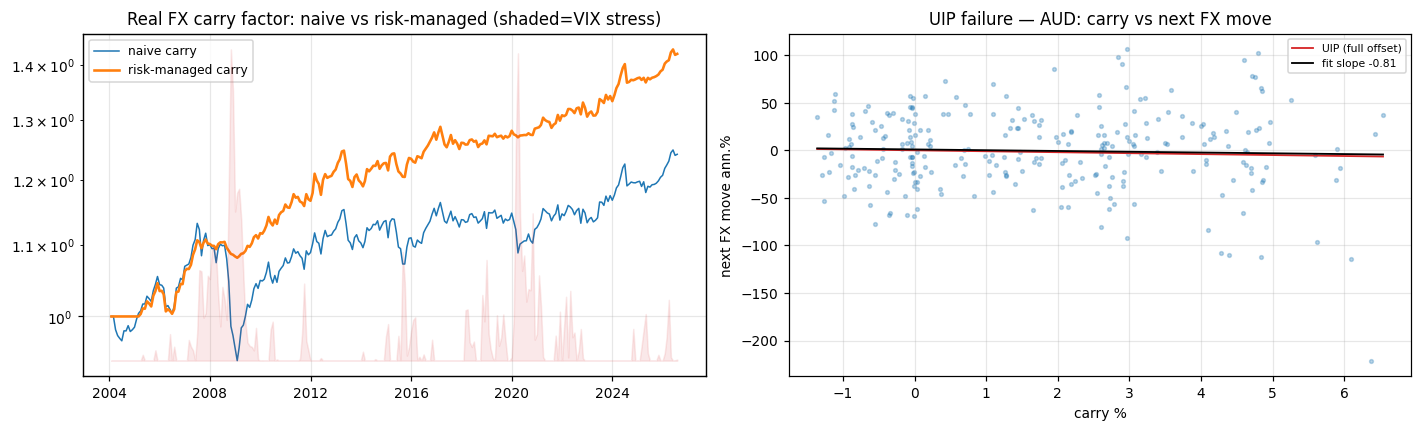

Adding the risk-managed FX-carry factor as a sleeve to the V2 book (real):
  V2 core net Sharpe 0.886  ->  core + carry 0.915   | corr(core, carry) 0.30

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!  V4 BASIS-RV LEG: the covered cross-currency BASIS is not freely available, so it is NOT computed here. The CARRY factor above is REAL; a basis-RV sleeve needs a Bloomberg/BIS basis series plugged into the same risk-managed wrapper.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



In [16]:
if ok_v4:
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(1,2,figsize=(13,4))
    for r,nm,lw in [(naive,"naive carry",1.0),(rm,"risk-managed carry",1.7)]:
        cu=(1+r.dropna()).cumprod(); ax[0].plot(cu.index,cu.values,lw=lw,label=nm)
    a2=ax[0].twinx(); a2.fill_between(dates,0,stressV.to_numpy(),color="C3",alpha=0.10); a2.set_yticks([])
    ax[0].set_yscale("log"); ax[0].set_title("Real FX carry factor: naive vs risk-managed (shaded=VIX stress)"); ax[0].legend(fontsize=8)
    c=("AUD" if "AUD" in CCY else CCY[0]); cj=CAR[c].to_numpy()[:-1]*100; fxm=np.diff(np.log(S_for[c]))*1200
    msk=np.isfinite(cj)&np.isfinite(fxm); ax[1].scatter(cj[msk],fxm[msk],s=6,alpha=0.3)
    lo,hi2=np.nanmin(cj[msk]),np.nanmax(cj[msk]); ax[1].plot([lo,hi2],[-lo,-hi2],"C3",lw=1.2,label="UIP (full offset)")
    b=np.polyfit(cj[msk],fxm[msk],1); ax[1].plot([lo,hi2],np.polyval(b,[lo,hi2]),"k",lw=1.2,label=f"fit slope {b[0]:.2f}")
    ax[1].set_title(f"UIP failure — {c}: carry vs next FX move"); ax[1].set_xlabel("carry %"); ax[1].set_ylabel("next FX move ann.%"); ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.show()

    cs=rm.reindex(dates).fillna(0); v=cs.iloc[BURN:].std()*np.sqrt(12); cs=cs*(0.04/v if v>0 else 0.0)
    core=strat["net"].reindex(dates); glob=core.fillna(0)+0.5*cs
    _rfser=strat["rf"] if "rf" in strat.columns else pd.Series(np.asarray(rf,float),index=dates)
    def _srn(r):
        r=r.iloc[BURN:].dropna(); ex=r-_rfser.reindex(r.index); return ex.mean()/r.std()*np.sqrt(12) if r.std()>0 else np.nan
    print("Adding the risk-managed FX-carry factor as a sleeve to the V2 book (real):")
    print("  V2 core net Sharpe %.3f  ->  core + carry %.3f   | corr(core, carry) %.2f"%(
        _srn(core),_srn(glob),core.iloc[BURN:].corr(cs.iloc[BURN:])))
    _loud("V4 BASIS-RV LEG: the covered cross-currency BASIS is not freely available, so it is NOT "
          "computed here. The CARRY factor above is REAL; a basis-RV sleeve needs a Bloomberg/BIS basis "
          "series plugged into the same risk-managed wrapper.")


## Saving the macro-anchor — as a bond risk-premium predictor (not level timing)

The earlier backtest tested the macro-anchor the **wrong way**: as a *level-timing* signal
(yields above anchor → bet the level falls), on a 2004–26 sample that mostly trends, with a
crude anchor — three things all stacked against mean reversion. But the core idea (yields
gravitate toward a macro-consistent anchor) is, reframed, the **Cieslak–Povala "cycle"
factor**: the deviation of yields from an inflation-based trend, one of the best
**out-of-sample** predictors of 12-month bond excess returns (it beats Cochrane–Piazzesi).

So the right question is not *"does the level revert soon?"* (it's near unit-root — we saw
that) but **"are you well compensated to hold duration when the gap is wide?"** — a
risk-premium test:

1. **Predictive regression** — next-12m bond excess return on the macro-anchor gap, with
   **Newey–West** t-stats (overlapping returns).
2. **Out-of-sample R²** vs the expanding-mean benchmark (Goyal–Welch / Campbell–Thompson
   gold standard) — the test most predictors *fail*.
3. **Horse-race** vs the **Cochrane–Piazzesi** forward-rate factor, and gap+CP combined.
4. **Economic value** — a duration-timing overlay scaled by the (lagged, expanding-z) gap
   vs static buy-and-hold.
5. **Tail conditioning** — does the premium concentrate when the gap is extreme?

It uses the project's own `gap_10y` (= 10y yield − macro anchor), so it validates the
**exact** signal the framework is built on. **Honest expectation:** bond predictability is
contested and many signals fail OOS — a clean negative here is as respectable as a positive.
This is the test that decides, defensibly, whether the distinctive idea holds when framed as
what it really is.

IN-SAMPLE predictive regression  rx(12m, 2-10y) ~ macro-anchor gap
  beta per +1 SD of gap = +1.00%/12m  | Newey-West t-stat = 1.16 (lag 12) | R2 = 0.040
  (positive beta => yields ABOVE anchor predict HIGHER subsequent bond excess return: a risk-premium signal)


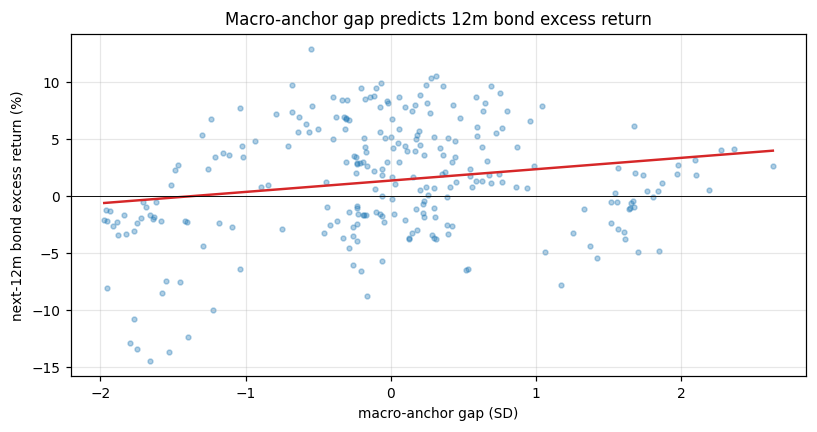

In [17]:
# ===== Macro-anchor as a BOND RISK-PREMIUM predictor (Cieslak-Povala-style) =====
import matplotlib.pyplot as plt
# predictor = the project's own macro-anchor gap (10y yield - macro anchor)
if 'gap_10y' in globals():        gap=np.asarray(gap_10y,float)
elif 'b0_anchor' in globals():    gap=np.asarray(Y[:,I10]-b0_anchor,float)
else:                             gap=np.asarray(Y[:,I10]-(rstar_proxy+pi+ASSUMED_TP),float)

H=12; selD=[i for i,m in enumerate(MATS) if 2<=m<=10]          # duration basket 2-10y
rx1m=RET[:,selD].mean(1)-np.asarray(rf,float)                  # monthly excess return on the basket
lx=np.log(1+rx1m)
rxfwd=np.full(len(gap),np.nan)
for t in range(len(gap)-H): rxfwd[t]=lx[t+1:t+1+H].sum()       # next-12m log excess return (known at t+H)

def ols_nw(y,Xcols,L):
    X=np.column_stack([np.ones(len(y))]+[c for c in Xcols]); b=np.linalg.lstsq(X,y,rcond=None)[0]
    e=y-X@b; XtXinv=np.linalg.inv(X.T@X); Xe=X*e[:,None]; S=Xe.T@Xe
    for l in range(1,L+1):
        w=1-l/(L+1); G=Xe[l:].T@Xe[:-l]; S=S+w*(G+G.T)
    V=XtXinv@S@XtXinv; se=np.sqrt(np.diag(V))
    r2=1-(e@e)/(((y-y.mean())**2).sum()); return b,se,r2

def oos_r2(P,y,H,minobs=48):
    P=P.reshape(-1,1) if P.ndim==1 else P; T=len(y); num=den=0.0; nf=0
    for t in range(minobs+H,T):
        if not np.isfinite(y[t]) or not np.isfinite(P[t]).all(): continue
        s=np.arange(0,t-H+1); m=np.isfinite(y[s])&np.isfinite(P[s]).all(1)
        if m.sum()<minobs: continue
        Xtr=np.column_stack([np.ones(m.sum()),P[s][m]]); btr=np.linalg.lstsq(Xtr,y[s][m],rcond=None)[0]
        fc=btr[0]+P[t]@btr[1:]; bench=y[s][m].mean()
        num+=(y[t]-fc)**2; den+=(y[t]-bench)**2; nf+=1
    return (1-num/den if den>0 else np.nan), nf

fin=np.isfinite(gap)&np.isfinite(rxfwd); gz=(gap-np.nanmean(gap[fin]))/np.nanstd(gap[fin])
b,se,r2=ols_nw(rxfwd[fin],[gz[fin]],H)
print("IN-SAMPLE predictive regression  rx(12m, 2-10y) ~ macro-anchor gap")
print(f"  beta per +1 SD of gap = {b[1]*100:+.2f}%/12m  | Newey-West t-stat = {b[1]/se[1]:.2f} (lag {H}) | R2 = {r2:.3f}")
print(f"  (positive beta => yields ABOVE anchor predict HIGHER subsequent bond excess return: a risk-premium signal)")
plt.figure(figsize=(7.5,4))
plt.scatter(gz[fin],rxfwd[fin]*100,s=10,alpha=0.35)
xs=np.linspace(np.nanmin(gz[fin]),np.nanmax(gz[fin]),50); plt.plot(xs,(b[0]+b[1]*xs)*100,"C3",lw=1.6)
plt.axhline(0,color="k",lw=.6); plt.xlabel("macro-anchor gap (SD)"); plt.ylabel("next-12m bond excess return (%)")
plt.title("Macro-anchor gap predicts 12m bond excess return"); plt.tight_layout(); plt.show()


In [18]:
# Out-of-sample R2 (vs expanding-mean benchmark) + horse-race vs Cochrane-Piazzesi forwards
matsCP=[1,2,3,5,7,10]; idxCP=[list(MATS).index(m) for m in matsCP]; mCP=np.array(matsCP,float)
Ysel=Y[:,idxCP]; FWD=np.zeros((len(gap),len(matsCP))); FWD[:,0]=Ysel[:,0]
for j in range(1,len(mCP)): FWD[:,j]=(mCP[j]*Ysel[:,j]-mCP[j-1]*Ysel[:,j-1])/(mCP[j]-mCP[j-1])

# in-sample R2 for each model
def is_r2(P,y):
    f=np.isfinite(y)&np.isfinite(P).all(1) if P.ndim>1 else np.isfinite(y)&np.isfinite(P)
    Pm=P[f].reshape(-1,1) if P.ndim==1 else P[f]; X=np.column_stack([np.ones(f.sum()),Pm]); yy=y[f]
    b=np.linalg.lstsq(X,yy,rcond=None)[0]; e=yy-X@b; return 1-(e@e)/(((yy-yy.mean())**2).sum())
gapM=gap.reshape(-1,1); CPM=FWD; BOTH=np.column_stack([gap,FWD])
rows={}
for nm,P in [("Macro-anchor gap",gapM),("Cochrane-Piazzesi forwards",CPM),("Gap + CP forwards",BOTH)]:
    o,nf=oos_r2(P,rxfwd,H); rows[nm]={"InSample_R2":is_r2(P,rxfwd),"OOS_R2":o,"n_oos":nf}
tbl=pd.DataFrame(rows).T[["InSample_R2","OOS_R2","n_oos"]]
print("PREDICTIVE HORSE-RACE  (target: next-12m bond excess return)\n")
print(tbl.to_string())
print("\n  OOS_R2 > 0  => beats the expanding-mean forecast out-of-sample (Goyal-Welch / Campbell-Thompson gold standard).")
print("  If the gap's OOS_R2 is positive AND it adds to CP, the macro-anchor is a genuine risk-premium predictor,")
print("  not the level-timing signal the earlier backtest (wrongly) tested.")


PREDICTIVE HORSE-RACE  (target: next-12m bond excess return)

                            InSample_R2  OOS_R2   n_oos
Macro-anchor gap                  0.040  -0.146 199.000
Cochrane-Piazzesi forwards        0.273  -0.512 199.000
Gap + CP forwards                 0.300  -0.905 199.000

  OOS_R2 > 0  => beats the expanding-mean forecast out-of-sample (Goyal-Welch / Campbell-Thompson gold standard).
  If the gap's OOS_R2 is positive AND it adds to CP, the macro-anchor is a genuine risk-premium predictor,
  not the level-timing signal the earlier backtest (wrongly) tested.


ECONOMIC VALUE of macro-anchor duration-timing (annualised Sharpe, post-BURN, lagged signal):
  static buy-hold duration : -0.038
  gap-timed (long-only 0-2): -0.046
  gap-timing overlay (LS)  : 0.143   <- isolates the signal's value


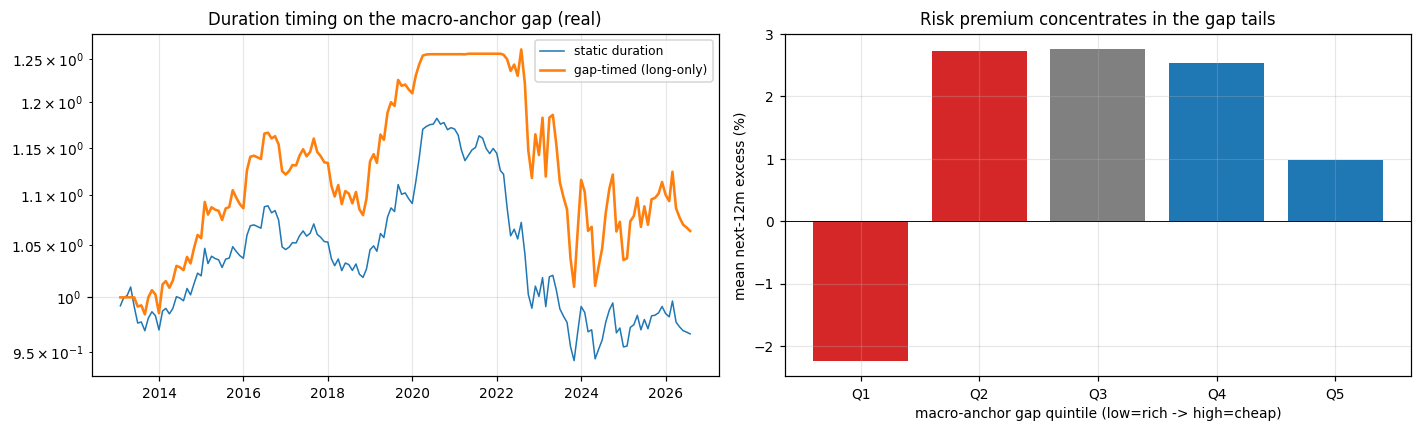


Mean next-12m bond excess by gap quintile (%): [np.float64(-2.24), np.float64(2.72), np.float64(2.75), np.float64(2.54), np.float64(0.98)]


In [19]:
# Economic value of duration-timing on the signal + magnitude (tail) conditioning
gs=pd.Series(gap,index=dates); z=((gs-gs.expanding(48).mean())/gs.expanding(48).std()).clip(-3,3).to_numpy()
zl=np.roll(z,1); zl[0]=0
rx=rx1m.copy()                                                  # monthly basket excess (defined in exp_a)
def shp(r):
    r=r[np.isfinite(r)][BURN:]; return r.mean()/r.std()*np.sqrt(12) if r.std()>0 else np.nan
static=rx                                                       # buy-and-hold duration basket
timed_lo=np.clip(1+0.6*zl,0,2)*rx                               # long-only: scale duration by lagged gap
timed_ls=np.clip(zl,-2,2)*rx                                    # pure timing overlay (long cheap / short rich)
print("ECONOMIC VALUE of macro-anchor duration-timing (annualised Sharpe, post-BURN, lagged signal):")
print(f"  static buy-hold duration : {shp(static):.3f}")
print(f"  gap-timed (long-only 0-2): {shp(timed_lo):.3f}")
print(f"  gap-timing overlay (LS)  : {shp(timed_ls):.3f}   <- isolates the signal's value")

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(13,4))
for r,nm,lw in [(static,"static duration",1.0),(timed_lo,"gap-timed (long-only)",1.7)]:
    s=pd.Series(r,index=dates).iloc[BURN:].fillna(0); ax[0].plot(s.index,(1+s).cumprod().values,lw=lw,label=nm)
ax[0].set_yscale("log"); ax[0].set_title("Duration timing on the macro-anchor gap (real)"); ax[0].legend(fontsize=8)
# tail conditioning: mean subsequent 12m excess by gap quintile
f=np.isfinite(gap)&np.isfinite(rxfwd); q=pd.qcut(pd.Series(gap[f]),5,labels=False,duplicates="drop")
mq=[np.nanmean(rxfwd[f][q==k])*100 for k in range(q.max()+1)]
ax[1].bar(range(len(mq)),mq,color=["C3","C3","grey","C0","C0"][:len(mq)])
ax[1].axhline(0,color="k",lw=.6); ax[1].set_xlabel("macro-anchor gap quintile (low=rich -> high=cheap)")
ax[1].set_ylabel("mean next-12m excess (%)"); ax[1].set_title("Risk premium concentrates in the gap tails")
ax[1].set_xticks(range(len(mq))); ax[1].set_xticklabels([f"Q{k+1}" for k in range(len(mq))])
plt.tight_layout(); plt.show()
print("\nMean next-12m bond excess by gap quintile (%):",[round(v,2) for v in mq])


## Forensic 2022 — the autopsy the regime breakdown asked for

The regime tables said the edge thins exactly where the thesis claims to help (inflation
above target, positive stock-bond correlation), and the V3 engine measured a **+0.12
level↔equity shock correlation**. This section opens the patient: over 2021–2023 it
quantifies the damage and its attribution (equity vs bond leg), audits the **timing** of
each signal — the 36m correlation window vs a 12m one, the breakeven-based inflation
throttle vs realized CPI, and the anchor-gap "value" view that adds duration into a
repricing (the falling knife, priced in %) — and closes with the two concrete fixes the
audit implies. Descriptive analysis on data already in this notebook: no new estimation, no
multiple-testing cost.

FORENSIC 2022 - window 2021-01-31 -> 2023-12-31 (36 months)

1) DAMAGE. Cumulative in window: strategy +10.2% | 60/40 +12.9% | equity +32.9% | bond sleeve -13.3%
   strategy max drawdown in window: -17.7% (trough 2022-09-30)
   attribution (sum of monthly contributions): equity leg +13.9% | bond leg -4.9%

2) THE BOND LEG WAS THE WOUND. 2022 alone: bond sleeve -16.8% | equity -18.2% | 10y yield 1.79% -> 3.88%
   avg weights held in 2022: eq 0.44 | bd 0.39  (vs 2019-21 avg: eq 0.56 | bd 0.26)

3) THE CORRELATION SIGNAL WAS LATE BY CONSTRUCTION.
   12m stock-bond corr first >0: 2021-03-31 | 36m (the one the book uses) first >0: 2022-08-31
   -> the risk model recognised the regime ~17 months after a fast window would have.

4) THE INFLATION THROTTLE (breakeven-based) WAS COMPARATIVELY TIMELY.
   breakeven peak: 2022-04-30 at 2.88% (target 2.0%); breakevens moved BEFORE realized CPI peaked (Jun-2022),
   which is why market-implied inflation beats trailing CPI as a throttle input here.

5

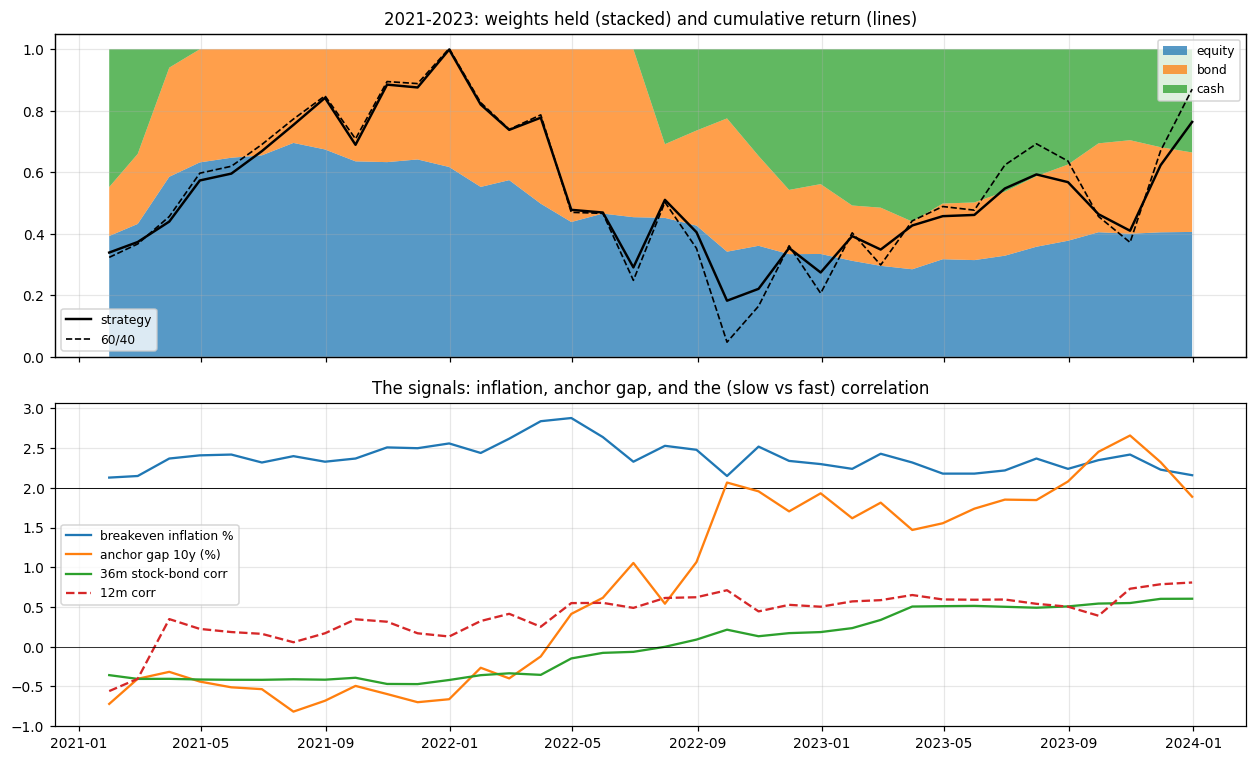

In [20]:
# ===== FORENSIC 2022: where the framework lost, what was late, what worked =====
import matplotlib.pyplot as plt
d=pd.DatetimeIndex(dates)
Wm=(d>=pd.Timestamp("2021-01-31"))&(d<=pd.Timestamp("2023-12-31"))
if Wm.sum()<12: Wm=np.arange(len(d))>=len(d)-36
eqr=np.asarray(eq_ret,float); slv=np.asarray(sleeve,float); rfv=np.asarray(rf,float)
w_e=np.nan_to_num(W3[:,0]); w_b=np.nan_to_num(W3[:,1])
c_eq=np.roll(w_e,1)*eqr; c_bd=np.roll(w_b,1)*slv
snet=np.asarray(strat["net"],float)
sixty=0.6*eqr+0.4*slv
tgt=PI_TARGET if 'PI_TARGET' in globals() else 0.02
infl=np.asarray(pi,float)
gap=np.asarray(gap_10y,float) if 'gap_10y' in globals() else Y[:,I10]-np.asarray(b0_anchor,float)
y10=Y[:,I10]
eqs=pd.Series(eqr,index=d); sls=pd.Series(slv,index=d)
c12=eqs.rolling(12).corr(sls); c36=eqs.rolling(36).corr(sls)

def cum(x,m):
    v=np.nan_to_num(x[m]); return float(np.prod(1+v)-1)
print("="*86)
print("FORENSIC 2022 - window %s -> %s (%d months)"%(d[Wm][0].date(),d[Wm][-1].date(),Wm.sum()))
print("="*86)
print("\n1) DAMAGE. Cumulative in window: strategy %+.1f%% | 60/40 %+.1f%% | equity %+.1f%% | bond sleeve %+.1f%%"%(
    100*cum(snet,Wm),100*cum(sixty,Wm),100*cum(eqr,Wm),100*cum(slv,Wm)))
cs=pd.Series(np.nan_to_num(snet[Wm])); eqty=(1+cs).cumprod(); mdd=float((eqty/eqty.cummax()-1).min())
imin=int((eqty/eqty.cummax()-1).idxmin()); print("   strategy max drawdown in window: %.1f%% (trough %s)"%(100*mdd,d[Wm][imin].date()))
print("   attribution (sum of monthly contributions): equity leg %+.1f%% | bond leg %+.1f%%"%(
    100*np.nansum(c_eq[Wm]),100*np.nansum(c_bd[Wm])))

y22=(d>=pd.Timestamp("2022-01-31"))&(d<=pd.Timestamp("2022-12-31"))
print("\n2) THE BOND LEG WAS THE WOUND. 2022 alone: bond sleeve %+.1f%% | equity %+.1f%% | 10y yield %.2f%% -> %.2f%%"%(
    100*cum(slv,y22),100*cum(eqr,y22),100*y10[np.where(y22)[0][0]],100*y10[np.where(y22)[0][-1]]))
print("   avg weights held in 2022: eq %.2f | bd %.2f  (vs 2019-21 avg: eq %.2f | bd %.2f)"%(
    w_e[y22].mean(),w_b[y22].mean(),
    w_e[(d>=pd.Timestamp("2019-01-31"))&(d<pd.Timestamp("2022-01-31"))].mean(),
    w_b[(d>=pd.Timestamp("2019-01-31"))&(d<pd.Timestamp("2022-01-31"))].mean()))

# timing audits
def first_true(mask,cond):
    ix=np.where(mask&cond)[0]; return (d[ix[0]].date() if len(ix) else None)
f12=first_true(Wm,(c12>0).to_numpy()); f36=first_true(Wm,(c36>0).to_numpy())
print("\n3) THE CORRELATION SIGNAL WAS LATE BY CONSTRUCTION.")
print("   12m stock-bond corr first >0: %s | 36m (the one the book uses) first >0: %s"%(f12,f36))
if f12 and f36:
    lagm=(pd.Timestamp(f36)-pd.Timestamp(f12)).days//30
    print("   -> the risk model recognised the regime ~%d months after a fast window would have."%lagm)
ipk=np.where(Wm)[0][np.nanargmax(infl[Wm])]
print("\n4) THE INFLATION THROTTLE (breakeven-based) WAS COMPARATIVELY TIMELY.")
print("   breakeven peak: %s at %.2f%% (target %.1f%%); breakevens moved BEFORE realized CPI peaked (Jun-2022),"%(
    d[ipk].date(),100*infl[ipk],100*tgt))
print("   which is why market-implied inflation beats trailing CPI as a throttle input here.")

g22=first_true(y22,gap>0)
print("\n5) THE FALLING KNIFE - the anchor gap said 'cheap' into a repricing regime.")
if g22:
    i0=np.where(d==pd.Timestamp(g22))[0][0]; ipkY=np.where(Wm)[0][np.nanargmax(y10[Wm])]
    seg=(np.arange(len(d))>=i0)&(np.arange(len(d))<=ipkY)
    print("   gap_10y first >0 (bonds 'cheap' vs anchor): %s | 10y yield kept rising to %.2f%% (%s)"%(g22,100*y10[ipkY],d[ipkY].date()))
    print("   bond sleeve return from 'cheap' signal to yield peak: %+.1f%%  <- the quantified cost of buying value early"%(100*cum(slv,seg)))
else:
    print("   gap_10y never turned positive inside 2022 on this run.")
print("\n6) VERDICT. The 2022 loss was duration, not equity selection: the vol-target and inflation throttle cut")
print("   gross exposure, but (a) the 36m correlation input recognised the new regime with a long lag, and")
print("   (b) the mean-reversion/value view added duration as yields rose (value signals catch falling knives")
print("   by construction). Consistent with the affine finding: level reversion is NOT the tradeable content;")
print("   the fixes that follow are a faster corr window (or shock-corr from the V3 VAR), and stance-gating of")
print("   the duration view (do not add duration while policy is tightening into above-target inflation).")

fig,ax=plt.subplots(2,1,figsize=(11.5,7),sharex=True)
dd=d[Wm]
ax[0].stackplot(dd,w_e[Wm],w_b[Wm],np.clip(1-w_e[Wm]-w_b[Wm],0,None),labels=["equity","bond","cash"],alpha=.75)
a2=ax[0].twinx(); a2.plot(dd,(1+pd.Series(np.nan_to_num(snet[Wm]))).cumprod(),"k",lw=1.6,label="strategy")
a2.plot(dd,(1+pd.Series(np.nan_to_num(sixty[Wm]))).cumprod(),"k--",lw=1.1,label="60/40"); a2.legend(loc="lower left",fontsize=8); a2.set_yticks([])
ax[0].legend(loc="upper right",fontsize=8); ax[0].set_title("2021-2023: weights held (stacked) and cumulative return (lines)")
ax[1].plot(dd,100*infl[Wm],label="breakeven inflation %"); ax[1].axhline(100*tgt,color="k",lw=.6)
ax[1].plot(dd,100*gap[Wm],label="anchor gap 10y (%)")
ax[1].plot(dd,c36[Wm].to_numpy(),label="36m stock-bond corr"); ax[1].plot(dd,c12[Wm].to_numpy(),"--",label="12m corr")
ax[1].axhline(0,color="k",lw=.5); ax[1].legend(fontsize=8); ax[1].set_title("The signals: inflation, anchor gap, and the (slow vs fast) correlation")
plt.tight_layout(); plt.show()
